<a href="https://colab.research.google.com/github/manarelkordy684-debug/Medical/blob/main/Medical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup
Install required packages and import core libraries.


In [ ]:
!pip uninstall -y transformers
!pip install transformers==5.5.0

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation
Define the raw medical symptom datasets as CSV strings and write them to disk.


In [ ]:
raw_data1 = """
text,label
حاسس بوجع شديد في أسفل بطني وبيجي مع الدورة,أمراض النساء والتوليد
دورتي اتأخرت شهرين وعاملة اختبار حمل طلع سلبي,أمراض النساء والتوليد
عندي إفرازات بيضا كتير وبتحس بحرقان في المنطقة,أمراض النساء والتوليد
بطني بيوجعني جامد قبل الدورة بأسبوع ويروح بعدها,أمراض النساء والتوليد
الدورة جت وكمية الدم كتير جداً ومش طبيعية بالنسبة لي,أمراض النساء والتوليد
حاسة بتقلصات في الرحم حتى من غير الدورة بشكل مزعج,أمراض النساء والتوليد
عندي حبة ظهرت في ثديي وبتوجعني لما بلمسها خصوصاً قبل الدورة,أمراض النساء والتوليد
الدورة جت بنص شهر بس وبتيجي كل شهرين من زمان,أمراض النساء والتوليد
حاسة بثقل في منطقة الحوض وصعب أقف فترة طويلة خصوصاً وقت الدورة,أمراض النساء والتوليد
عندي ألم مع الجماع بيخليني أتجنبه تماماً من فترة,أمراض النساء والتوليد
إفرازات صفرا وريحتها وحشة وعندي حكة شديدة في المهبل,أمراض النساء والتوليد
بحس بامتلاء في البطن الأيسر وكأن في حاجة ضاغطة جوايا,أمراض النساء والتوليد
اكتشفت إن عندي كيسة في المبيض الدكتور قالها عند الأشعة,أمراض النساء والتوليد
مش حاسة بأي أعراض بس التحاليل طلعت هرمونات ناقصة,أمراض النساء والتوليد
دورتي جت والدم فيها بقع بنية قبل ما تبدأ بيومين كل شهر,أمراض النساء والتوليد
بنزل دم بين الدورات من غير سبب واضح وبخاف,أمراض النساء والتوليد
حاسة بتورم في الثدي وبألم خصوصاً قبل الدورة بأسبوع,أمراض النساء والتوليد
بطني كبر في أسبوعين مش عارفة هو وزن ولا حاجة تانية جوايا,أمراض النساء والتوليد
عندي التهاب متكرر في المهبل ومش بيتحسن مع العلاج العادي,أمراض النساء والتوليد
الدورة وقفت من سنتين وعندي 38 سنة بس مش حامل,أمراض النساء والتوليد
حاسة بوجع في الظهر السفلي مع كل دورة بيزيد أول يومين,أمراض النساء والتوليد
عندي حرقان في البول مع نزول دم خفيف وعندي ألم في البطن وقت الدورة,أمراض النساء والتوليد
الدكتورة قالتلي في الأشعة إن في ألياف في الرحم,أمراض النساء والتوليد
حاسة إن في ضغط على المثانة وبتحش كتير خصوصاً قبل الدورة,أمراض النساء والتوليد
حملت وعندي بقع دم وخايفة على الحمل من الإجهاض,أمراض النساء والتوليد
من ساعة ما ولدت وأنا حاسة بعدم إحساس في المنطقة التناسلية,أمراض النساء والتوليد
الحيض بقى أسود اللون ومعاه تكتل دم كتير ومؤلم,أمراض النساء والتوليد
عندي ألم شديد في الكتف الأيمن مع ألم في البطن السفلي وقت الدورة,أمراض النساء والتوليد
بعد الجماع بيجي دم خفيف وعندي ألم في عنق الرحم,أمراض النساء والتوليد
مبايضي مش شغالة وتحاليل الخصوبة طلعت وحشة والدكتور قال,أمراض النساء والتوليد
حاسة بثقل في الجهة الأيمن من الحوض خصوصاً لما أقف,أمراض النساء والتوليد
حاسة إن في حاجة بتنزل لتحت في منطقة المهبل زي هبوط,أمراض النساء والتوليد
الدورة بتيجي كل 21 يوم بدل 28 من سنين,أمراض النساء والتوليد
عندي حكة في الفرج من غير إفرازات واضحة بتخليني مش قادرة أنام,أمراض النساء والتوليد
من بعد العملية القيصرية حاسة بألم في مكان الجرح خصوصاً مع الحركة,أمراض النساء والتوليد
حاسة بغثيان الصبح بس الاختبار طلع سلبي ومعايا أعراض تانية,أمراض النساء والتوليد
الدورة بقت مؤلمة جداً وبآخد مسكنات قوية عشان أقدر أتحمل,أمراض النساء والتوليد
في إفرازات خضرا وعندي حرارة خفيفة وتعب مع ألم في البطن,أمراض النساء والتوليد
حاسة بتكتل في الإبط وخايفة يكون له علاقة بالثدي,أمراض النساء والتوليد
دورتي جت وكمية الدم قليلة جداً وبتعدي في يومين بس,أمراض النساء والتوليد
حاسة بتنميل في منطقة الفرج من غير سبب واضح وقلقاني,أمراض النساء والتوليد
بكاء وعصبية شديدة قبل الدورة بأسبوع وكأني مش أنا,أمراض النساء والتوليد
حاسة بإرهاق شديد جداً مع الدورة حتى مش قادرة أصحى من السرير,أمراض النساء والتوليد
حاسة إن حاجة بتاكل في بطني من جوه خصوصاً الليل وقت الدورة,أمراض النساء والتوليد
عندي ألم يمتد من البطن للظهر ولرجلي أثناء الدورة,أمراض النساء والتوليد
من بعد الولادة ما قدرتش أحمل تاني وبدور على السبب,أمراض النساء والتوليد
حاسة بدوخة شديدة مع الدورة وبغمى عليا كمان من شدة الألم,أمراض النساء والتوليد
عندي حبوب في الثدي بتزيد مع الدورة وبتروح بعدها بكم يوم,أمراض النساء والتوليد
حاسة بضغط في المثانة وصعوبة في الجلوس فترة طويلة,أمراض النساء والتوليد
الدورة بقت معاها إسهال ورعشة وتقيؤ من شدة الألم,أمراض النساء والتوليد
لما بجري أو بمشي بسرعة بحس بثقل في البطن السفلي,أمراض النساء والتوليد
حاسة بحرق في الثدي الأيمن من غير حاجة واضحة,أمراض النساء والتوليد
بعد الإجهاض حاسة بأكتئاب شديد ووجع نفسي وجسدي,أمراض النساء والتوليد
حاسة بوجع لما بحاول أتبول وفي دم خفيف في البول وقت الدورة,أمراض النساء والتوليد
عندي ألم في الكوع والأصابع مع ألم في أسفل البطن وقت الدورة,أمراض النساء والتوليد
حاسة بوجع شديد في جنب الأيمن وبيشع للأرجل مع الدورة,أمراض النساء والتوليد
إفرازات بيضا وكثيفة زي الجبنة وعندي حكة موحشة في المهبل,أمراض النساء والتوليد
حاسة بانتفاخ في البطن وكأني حامل وأنا مش كده,أمراض النساء والتوليد
الدورة وقفت من 6 شهور ومعمولة هرمونات بس مش بتيجي,أمراض النساء والتوليد
حاسة بوجع لما بلمس منطقة تحت السرة خصوصاً وقت الدورة,أمراض النساء والتوليد
بعد الولادة الدم ما وقفش من 3 أسابيع ومقلقني,أمراض النساء والتوليد
حاسة بحرقان وإحساس مزعج في منطقة الحوض طول اليوم,أمراض النساء والتوليد
عندي التهاب في المبيض والدكتورة قالت محتاجة علاج طويل,أمراض النساء والتوليد
حاسة بنغزة في جانب الرحم الأيمن كده فجأة وتروح,أمراض النساء والتوليد
مش قادرة أحمل من 4 سنين والتحاليل كلها تمام ومفيش سبب,أمراض النساء والتوليد
دورتي بتيجي مرتين في الشهر وكمية الدم كتير جداً,أمراض النساء والتوليد
حاسة بضغط مزعج في منطقة المثانة طول الوقت حتى بعد التبول,أمراض النساء والتوليد
عندي وجع في الظهر السفلي مع غثيان بدون دورة,أمراض النساء والتوليد
شعري بيتساقط كتير والدكتور قال ممكن بسبب هرمونات,أمراض النساء والتوليد
حاسة بوجع في مبيضي الأيسر بيشع للفخد الأيسر,أمراض النساء والتوليد
عندي حرارة مع إفرازات وحشة وألم في البطن وقت الدورة,أمراض النساء والتوليد
الأشعة اتضح فيها إن في سائل في البطن من غير سبب معروف,أمراض النساء والتوليد
حاسة بصعوبة في الحركة مع الدورة وعايزة أبقى تابتة في السرير,أمراض النساء والتوليد
عندي تورم في الرجلين مع ألم في أسفل البطن وقت الدورة,أمراض النساء والتوليد
دورتي وقفت ومش عارفة هي بيداية سن اليأس ولا حاجة تانية,أمراض النساء والتوليد
بتألم من ناحية الأيمن وبيشع للفخد الأيمن مع الدورة,أمراض النساء والتوليد
حاسة بوجع شديد في العانة لما أقوم من النوم خصوصاً وقت الدورة,أمراض النساء والتوليد
عندي كتمة في الصدر مع تأخر الدورة وخايفة أكون حامل,أمراض النساء والتوليد
الدورة جت سوداء وكمية قليلة ومعاها تكتلات مؤلمة,أمراض النساء والتوليد
حاسة بثقل في حوضي كأني شايلة حمل تقيل طول الوقت,أمراض النساء والتوليد
عندي حساسية في جلد الثدي وبيتقشر من غير سبب واضح,أمراض النساء والتوليد
من بعد وضع اللولب وأنا بحس بوجع مستمر في الرحم,أمراض النساء والتوليد
حاسة بانتفاخ في الصفحة اليمين من البطن السفلي وقت الدورة,أمراض النساء والتوليد
عندي ألم مع التبول من غير التهاب وعملت تحاليل تمام,أمراض النساء والتوليد
الدكتورة شافت في الأشعة إن الرحم متضخم شوية,أمراض النساء والتوليد
حاسة بوجع مستمر في منطقة المبيضين من غير دورة,أمراض النساء والتوليد
دورتي جت بعد 3 شهور غياب وكانت فيها ألم شديد جداً,أمراض النساء والتوليد
حاسة بحرق في الجلد من حوالين الثدي مع احمرار,أمراض النساء والتوليد
مش قادرة أنام من الألم في أسفل البطن أول يوم دورة,أمراض النساء والتوليد
عندي وجع في المفاصل مع ألم في مبيضي وقت الدورة,أمراض النساء والتوليد
حاسة بعدم انتظام في الضربات مع تأخر الدورة وقلق,أمراض النساء والتوليد
بحس برعشة ووجع تحت السرة ليلاً بس وقت الدورة,أمراض النساء والتوليد
إفرازات لونها بني قبل الدورة بأسبوع كل مرة,أمراض النساء والتوليد
حاسة بوجع في المبيض الأيمن لما بجلس على الأرض,أمراض النساء والتوليد
التحاليل طلعت في كيسة في المبيض الأيمن مقاسها 4 سم,أمراض النساء والتوليد
حاسة بانتفاخ في البطن الكامل مع الدورة وصعوبة في التنفس,أمراض النساء والتوليد
حاسة بوجع خلف الركبة مع ألم في أسفل الظهر والحوض وقت الدورة,أمراض النساء والتوليد
شايفة بقع حمرا في جلد الثدي وخايفة على نفسي يكون سرطان,أمراض النساء والتوليد
من بعد الولادة بالقيصرية والجرح دايماً بيجرح وينفتح,أمراض النساء والتوليد
عندي ألم حاد في الكتف أثناء الدورة مش عارفة ليه,أمراض النساء والتوليد
عندي إفرازات وردية اللون من غير دورة وخايفة يكون حمل,أمراض النساء والتوليد
حاسة بضغط على المستقيم مع الألم في الحوض وقت الدورة,أمراض النساء والتوليد
حاسة بخفقان في الصدر مع الدورة وتعب شديد جداً,أمراض النساء والتوليد
بحس بألم نابض في منطقة الرحم كل يوم من غير دورة,أمراض النساء والتوليد
عندي تكيس في المبايض والدكتور قال ممكن يأثر على الحمل,أمراض النساء والتوليد
حاسة بأعراض الدورة بس الدورة مش جاية من 3 شهور,أمراض النساء والتوليد
حاسة بتنميل في الجانب الأيمن من البطن السفلي وقت الدورة,أمراض النساء والتوليد
من سنة وأنا بعاني من ألم شديد في أسفل بطني بيزيد قبل الدورة بأسبوع وبيستمر لدخول الدورة,أمراض النساء والتوليد
الدورة عندي مش منتظمة خالص وبتجي كل 45 يوم تقريباً ومعاها ألم لا يوصف,أمراض النساء والتوليد
بعد ما ولدت قيصري وأنا حاسة بألم في مكان الجرح كل ما بتحرك أو بلمسه,أمراض النساء والتوليد
الدكتورة قالت عندي تكيس على المبيضين وألم مزمن في الحوض بقاله سنين,أمراض النساء والتوليد
الدورة بتجيلي غزيرة جداً أول يومين لدرجة إني بضطر أغير الفوطة كل ساعة,أمراض النساء والتوليد
حاسة بتغيرات مزاجية حادة قبل الدورة بتخليني أعصب من أي حاجة وأبكي بسهولة,أمراض النساء والتوليد
حاسة بضغط شديد على المثانة خصوصاً قبل الدورة وبتبول كل شوية,أمراض النساء والتوليد
حاسة إن في حاجة نازلة من المهبل زي كرة صغيرة خصوصاً بعد ما أقف كتير,أمراض النساء والتوليد
بقالي 5 سنين بحاول أحمل ومش بيحصل ومعمولة كل التحاليل ومفيش سبب,أمراض النساء والتوليد

أذني بتوجعني جامد ومحساش بيها من امبارح,أنف وأذن وحنجرة
عندي وجع في الحلق وصعوبة في البلع من 4 أيام,أنف وأذن وحنجرة
حاسس إن في حاجة واقفة في حلقي وصعب أبلع,أنف وأذن وحنجرة
أنفي مسكر خالص وما فيش هوا بيعدي منه,أنف وأذن وحنجرة
بسمع طنين في ودني من الصبح وما اتحسنش,أنف وأذن وحنجرة
حاسس بطنين في ودني اليمين زي صوت مستمر,أنف وأذن وحنجرة
لساني محساش بيه كويس والطعم اتغير عندي,أنف وأذن وحنجرة
زوري مؤلم وفيه كتل حمرا في أول الحلق,أنف وأذن وحنجرة
حاسس بدوخة شديدة بسبب التهاب في الأذن الداخلية,أنف وأذن وحنجرة
صوتي اتغير ومش زيه الأول وبقى أجش,أنف وأذن وحنجرة
حاسس بسيلان كتير من أنفي وعيني بتدمع,أنف وأذن وحنجرة
بكح كتير بسبب تنقيط أنفي خلفي مش من الصدر,أنف وأذن وحنجرة
وجعني حلقي ولوزتي منتفخة وحمرا,أنف وأذن وحنجرة
حاسس بامتلاء في وداني وبسمع ضعيف,أنف وأذن وحنجرة
أنفي بينزل منه دم بدون سبب واضح,أنف وأذن وحنجرة
حاسس بصعوبة في الكلام وصوتي بقى ضعيف,أنف وأذن وحنجرة
وجعني ودني اليسار وفيه إفرازات صفرا,أنف وأذن وحنجرة
بحس بثقل في وشي وضغط حول عيني وأنفي,أنف وأذن وحنجرة
حاسس بضغط في ودني لما بصعد سلم أو بيت المصعد,أنف وأذن وحنجرة
حلقي بيجرحني وعندي بقع بيضا على اللوزتين,أنف وأذن وحنجرة
حاسس بميل لجهة الشمال وصعوبة في الوقوف بسبب الأذن,أنف وأذن وحنجرة
عندي صداع فوق العيون مع ضغط في الأنف,أنف وأذن وحنجرة
بكح كتير بالليل بسبب تنقيط أنفي,أنف وأذن وحنجرة
صوتي مش خارج كويس وبشتكي من بحة,أنف وأذن وحنجرة
حاسس بأن في حاجة بتسيل من ورا حلقي ليل نهار,أنف وأذن وحنجرة
بحس بانسداد في ودني وكأن في ماية جوه,أنف وأذن وحنجرة
وجعني ودني وبطلع منه سائل أصفر,أنف وأذن وحنجرة
حاسس بألم شديد لما بحاول أفتح بوقي,أنف وأذن وحنجرة
عندي شخير شديد بالليل بسبب انسداد الأنف,أنف وأذن وحنجرة
حاسس إن حاسة الشم راحت منذ أسبوع,أنف وأذن وحنجرة
بسمع صوت طق في ودني لما ببلع,أنف وأذن وحنجرة
وجعني حلقي من أسبوع ومش بيتحسن وبعيط منه,أنف وأذن وحنجرة
حاسس بوجع في الفك السفلي مع وجع في الحلق,أنف وأذن وحنجرة
لما بضغط على أنفي بحس بألم شديد,أنف وأذن وحنجرة
صوتي بقى أجش من بعد الزكام ومش راجع,أنف وأذن وحنجرة
عندي التهاب في الجيوب الأنفية وصداع في الجبهة,أنف وأذن وحنجرة
حاسس بصعوبة في التنفس من الأنف فقط والف مفتوح,أنف وأذن وحنجرة
وجعني حلقي وحاسس إن في كتلة على جانبه,أنف وأذن وحنجرة
بحس بدوخة لما أقوم من النوم بسرعة بسبب الأذن,أنف وأذن وحنجرة
عندي كحة جافة بتصحيني من النوم بسبب الأنف,أنف وأذن وحنجرة
حاسس بألم خلف أذني وامتد للفك,أنف وأذن وحنجرة
بتسيل عيني من غير بكا مع إحساس بضغط في الجبهة,أنف وأذن وحنجرة
حاسس بثقل في رأسي وكأن في ضغط حوله,أنف وأذن وحنجرة
عندي سيلان في الأنف من ناحية واحدة بس,أنف وأذن وحنجرة
بسمع صوت مائي في ودني لما بحرك راسي,أنف وأذن وحنجرة
حاسس بألم في زوري لما باكل الأكل الحامض,أنف وأذن وحنجرة
وجعني وداني الاثنين وحاسس بكتمة خفيفة بسبب انسداد الأذن,أنف وأذن وحنجرة
حاسس بوجع في رقبتي مع ألم في حلقي,أنف وأذن وحنجرة
حاسس بأن في سائل في ودني ومعاه وجع,أنف وأذن وحنجرة
بحس بغربشة في ودني كل ما صحيت,أنف وأذن وحنجرة
أنفي بيتسد كل ليلة وأنا بنام ومش قادر أتنفس من أنفي,أنف وأذن وحنجرة
حاسس بوجع تحت الفك وعقدة متورمة,أنف وأذن وحنجرة
عندي وجع في الأذن بيشع للرقبة,أنف وأذن وحنجرة
صوتي مش بييجي خالص من يوم امبارح,أنف وأذن وحنجرة
حاسس بشد في عضلات الحلق لما ببتلع,أنف وأذن وحنجرة
بيجرحني وراء أذني لما ألمسه,أنف وأذن وحنجرة
حاسس بتنميل في جانب اللسان من الشمال,أنف وأذن وحنجرة
عندي كحة نهاري مع سيلان في الأنف,أنف وأذن وحنجرة
حاسس بصوت زير مستمر في ودني اليمين,أنف وأذن وحنجرة
بحس بامتلاء وضغط في جيوبي الأنفية,أنف وأذن وحنجرة
حاسس بصعوبة في التوازن وكأني شرب كحول بسبب الأذن,أنف وأذن وحنجرة
عندي شخير بالليل وبقيت أصحى على إحساس بضيق بسبب الأنف,أنف وأذن وحنجرة
حاسس إن في حاجة بتنزل من الأنف لجوف الحلق,أنف وأذن وحنجرة
صوتي اتغير وبقى أرفع وأضعف من قبل,أنف وأذن وحنجرة
عندي ألم في الجيب الأنفي الأيمن فقط,أنف وأذن وحنجرة
حاسس بوجع في وداني لما بنفخ أنفي,أنف وأذن وحنجرة
بسمع صوت بلع مستمر زي ما حاجة بتنزل,أنف وأذن وحنجرة
عندي سيلان أنف أحمر مع دم خفيف,أنف وأذن وحنجرة
حاسس بألم في لساني ومش قادر أتكلم صح,أنف وأذن وحنجرة
عندي صداع خلف الأذنين مع دوخة,أنف وأذن وحنجرة
حاسس بحكة داخل أذني طول اليوم,أنف وأذن وحنجرة
وجعني حلقي وبحس بحرارة فيه,أنف وأذن وحنجرة
حاسس بوجع خلف الأنف لما بضغط,أنف وأذن وحنجرة
صوتي بقى ضبابي وبنزل نفسي كتير لما بتكلم,أنف وأذن وحنجرة
عندي إحساس مستمر بأن في حاجة مدفونة في حلقي,أنف وأذن وحنجرة
حاسس بألم عميق في ودني اليسار وطنين,أنف وأذن وحنجرة
بحس بحرقان في الحلق بعد الأكل زي ما حاجة بتيجي لفوق,أنف وأذن وحنجرة
عندي وجع في وداني بيزيد لما بنام على جنبي,أنف وأذن وحنجرة
حاسس بأن في ماية في ودني وبيسمع صوت عند الحركة,أنف وأذن وحنجرة
صوتي مش خارج كويس ومش قادر أكمل جملة,أنف وأذن وحنجرة
حاسس بحرقان في الأنف والعيون لما بيجي الربيع,أنف وأذن وحنجرة
عندي ألم في قمة رأسي مع سيلان أنف مستمر,أنف وأذن وحنجرة
بحس بأذني بتطق لما ببلع,أنف وأذن وحنجرة
حاسس بحرقان في الحلق من غير أكل من الصبح,أنف وأذن وحنجرة
حاسس بأن في ورم في الحلق وبيكبر,أنف وأذن وحنجرة
وجعني وراء ودني وامتد لرقبتي,أنف وأذن وحنجرة
حاسس بوجع في لوزتي بيزيد وبيقل,أنف وأذن وحنجرة
عندي دوخة بتيجي فجأة وبتفوت بعد شوية بسبب الأذن,أنف وأذن وحنجرة
حاسس بصعوبة في فتح فمي الصبح بعد النوم,أنف وأذن وحنجرة
بشوف الدنيا بتلف معايا لما أنظر يمين وشمال بسبب الأذن,أنف وأذن وحنجرة
عندي كحة رطبة مع بلغم من الأنف مش من الصدر,أنف وأذن وحنجرة
حاسس بألم خلف الحنك لما بابلع,أنف وأذن وحنجرة
حاسس بضعف في السمع في الودن اليمين فجأة,أنف وأذن وحنجرة
بحس بدوخة مع غثيان وبقيء لما بتحرك بسبب الأذن,أنف وأذن وحنجرة
عندي ألم في منطقة الجيب الأنفي فوق الأنف,أنف وأذن وحنجرة
حاسس بوجع في وداني وبيطلع منها سائل كريه,أنف وأذن وحنجرة
صوتي بقى غريب وبيخنشق وأنا بتكلم,أنف وأذن وحنجرة
حاسس بألم في رقبتي مع صعوبة في بلع الأكل,أنف وأذن وحنجرة
وجعني حلقي بالشمال بس وبيشع للأذن,أنف وأذن وحنجرة
بحس بوجع شديد خلف ودني لما بيجي البرد,أنف وأذن وحنجرة
حاسس بصوت نفير في ودني وبيزيد ليلاً,أنف وأذن وحنجرة
بقيت أعطس كتير الصبح مع سيلان ودموع,أنف وأذن وحنجرة
عندي ألم في فمي خلف الأسنان وفي الحنك,أنف وأذن وحنجرة
حاسس بنغزة في ودني بتيجي وبتروح,أنف وأذن وحنجرة
من أسبوع وأنا حاسس بانسداد كامل في أنفي ومش قادر أتنفس من خشمي خالص,أنف وأذن وحنجرة
أذني الشمال ورمت وحمرت وبيطلع منها إفرازات صفرا وريحتها وحشة,أنف وأذن وحنجرة
حاسة بطنين مستمر في ودني اليمين بقاله شهر وبيزيد بالليل ومخليني مش قادر أنام,أنف وأذن وحنجرة
لما بابتلع بحس بألم شديد في حلقي وكأن في حاجة جرحاني جوه,أنف وأذن وحنجرة
صوتي راح خالص من تلات أيام ومش قادر أتكلم حتى بالهمس,أنف وأذن وحنجرة
أنفي بينزل منه إفرازات خضرا سميكة من ناحية واحدة بس من أسبوع,أنف وأذن وحنجرة
حاسة بدوخة شديدة وعدم اتزان وكل ما بلف راسي الدنيا بتلف معايا,أنف وأذن وحنجرة
لما بصحى من النوم بلاقي حلقي جاف ومحرق وعندي كحة,أنف وأذن وحنجرة
البلغم بينزل من أنفي للحلق طول اليوم وبيخليني اتكح,أنف وأذن وحنجرة
أذني اليمين واقعة ومش سامع منها كويس من بعد ما خدت ضربة,أنف وأذن وحنجرة
حاسة بحكة شديدة في ودني جوا ومش قادرة أوقف حكها,أنف وأذن وحنجرة
لما بفرد فمي بحس بألم شديد في فكي قرب ودني,أنف وأذن وحنجرة
من بعد ما ركبت الطيارة وداني مسدودة وبيوجعني لما ببلع,أنف وأذن وحنجرة
حاسس بوجود جسم غريب في حلقي زي شعرة أو ريشة طول اليوم,أنف وأذن وحنجرة
لما باكل حاجة سخنة عيني بتدمع وأنفي بيسيل,أنف وأذن وحنجرة
ابني عنده ألم في ودنه وبيصرخ وبيشد على ودنه,أنف وأذن وحنجرة
حاسة بطعم غريب في فمي زي المرارة من كام يوم,أنف وأذن وحنجرة
أنفي بيوجعني من الناحية الشمال لما بلمسه من بره,أنف وأذن وحنجرة
بصوتي بقى مبحوح من أسبوع ومش بيتحسن ومش عارفة السبب,أنف وأذن وحنجرة

معدتي بتوجعني بعد الأكل مباشرة كل يوم,الأمراض الباطنية
حاسس بحموضة شديدة في معدتي بالليل,الأمراض الباطنية
بتقيأ بعد الأكل من غير ما أحس بغثيان قبلها,الأمراض الباطنية
بطني منتفخ طول اليوم وفيه غازات كتير,الأمراض الباطنية
حاسس بوجع في معدتي بيشع للظهر,الأمراض الباطنية
عندي إسهال من 3 أيام وتعبان جداً,الأمراض الباطنية
حاسس بإمساك شديد ومش قادر أصرف من 5 أيام,الأمراض الباطنية
بطلع دم مع البراز وخايف,الأمراض الباطنية
حاسس بثقل وامتلاء في معدتي حتى لو ماكلتش,الأمراض الباطنية
بحس بحرقان في الصدر بعد كل أكله,الأمراض الباطنية
وزني نزل 7 كيلو في شهر من غير ريجيم,الأمراض الباطنية
حاسس بوجع في كبدي الجهة اليمين,الأمراض الباطنية
بصفر لوني ولون عيني اصفرت,الأمراض الباطنية
حاسس بإعياء شديد مع فقدان شهية كامل,الأمراض الباطنية
بطني بيوجعني حول السرة وبيتحرك الوجع,الأمراض الباطنية
بيجيلي غثيان كل ما أشم ريحة الطعام,الأمراض الباطنية
بطني بيوجعني في الجانب الأيسر السفلي,الأمراض الباطنية
حاسس بضغط في الصدر بعد الأكل,الأمراض الباطنية
عندي اسهال متقطع مع إمساك وبراز متغير,الأمراض الباطنية
بطلع مخاط في البراز من فترة,الأمراض الباطنية
حاسس بوجع في منطقة المرارة بعد الأكل الدسم,الأمراض الباطنية
حاسس بتعب شديد وبحس إن كبدي ثقيل,الأمراض الباطنية
بحس بحرقان في المريء من البطن لحد الحلق,الأمراض الباطنية
عندي تغيير في الشهية وبقيت مش عايز آكل خالص,الأمراض الباطنية
حاسس بانتفاخ في الجهة اليمين العلوية,الأمراض الباطنية
بطني بيوجعني وبعدين بيجيلي إسهال,الأمراض الباطنية
بحس بغثيان الصبح بدون ما آكل حاجة,الأمراض الباطنية
عندي ارتجاع معدي بيصحيني من النوم,الأمراض الباطنية
البراز بقى أسود اللون وخايف,الأمراض الباطنية
عندي قرح في المعدة والدكتور اكدها بالمنظار,الأمراض الباطنية
بحس بغثيان وبتقيأ مرة واحدة في اليوم كل يوم,الأمراض الباطنية
بطني بيوجعني بالليل وبيصحيني من النوم,الأمراض الباطنية
حاسس بوجع فوق السرة وتحت الضلوع,الأمراض الباطنية
بحس بامتلاء شديد لو اتكلت قليل,الأمراض الباطنية
عندي حرقان في المعدة بيزيد مع القهوة,الأمراض الباطنية
حاسس بضغط في المعدة وكأن في حاجة مضغوطة,الأمراض الباطنية
بتألم في بطني وبيجيلي صداع مع التعب,الأمراض الباطنية
عندي انتفاخ في الصفحة اليسارية,الأمراض الباطنية
بحس بألم مستمر في أسفل الصدر الأيسر,الأمراض الباطنية
حاسس بوجع في مناطق مختلفة من البطن ومش محدد,الأمراض الباطنية
عندي تغيير ملحوظ في البراز من يومين,الأمراض الباطنية
بطني بيوجعني وبيتحسن بعد أروح الحمام,الأمراض الباطنية
حاسس بثقل في الجهة العلوية من البطن,الأمراض الباطنية
بتقيأ ومعاه وجع شديد في البطن,الأمراض الباطنية
عندي فقدان وزن مع تعب وفقدان شهية,الأمراض الباطنية
بحس بحرقة وسط الصدر لما بنام,الأمراض الباطنية
حاسس بوجع في بطني وبيشع للكتف الأيمن,الأمراض الباطنية
عندي إسهال مع تشنجات في البطن,الأمراض الباطنية
بطني بينتفخ لما بشرب اللبن,الأمراض الباطنية
حاسس بتشنجات في بطني زي ما القولون بيتقبض,الأمراض الباطنية
بحس بوجع في الجهة اليمين السفلية وخايف زايدة,الأمراض الباطنية
عندي عسر هضم مستمر حتى لو ما اكلتش حاجة صعبة,الأمراض الباطنية
بتألم في بطني ومش قادر أنام على وضع معين,الأمراض الباطنية
حاسس بثقل وانتفاخ مع إمساك منذ أسبوع,الأمراض الباطنية
بحس بقلق في بطني كل ما بيجيلي ضغط,الأمراض الباطنية
عندي وجع في معدتي وحاسس بغثيان وتعب,الأمراض الباطنية
حاسس بوجع تحت الضلوع الأيسر,الأمراض الباطنية
بطلع دم في القيء وخايف جداً,الأمراض الباطنية
عندي التهاب في الكبد والتحاليل طلعت إنزيمات عالية,الأمراض الباطنية
بحس بدوخة وتعب مع فقدان الشهية وصفار في العيون,الأمراض الباطنية
حاسس بوجع مستمر في منطقة البنكرياس,الأمراض الباطنية
بتألم في بطني بعد الأكل بساعة وبيروح بعدين,الأمراض الباطنية
عندي إسهال وبطني ينتفخ بسرعة بعد الأكل,الأمراض الباطنية
بحس بالتعب والإعياء مع فقدان وزن,الأمراض الباطنية
حاسس بحرقة في بطني ومش عارف هي معدة ولا حاجة,الأمراض الباطنية
بتألم في جانب الأيمن وبيشع للظهر,الأمراض الباطنية
عندي قولون عصبي وبتألم بشكل مستمر,الأمراض الباطنية
بحس بانتفاخ شديد وغازات بتخرج منى كتير,الأمراض الباطنية
حاسس بوجع في معدتي بيبدأ الصبح وبيروح بعد الأكل,الأمراض الباطنية
بطلع في البراز مخاط وعندي ألم في البطن,الأمراض الباطنية
عندي إحساس بامتلاء مستمر مع انتفاخ مستمر,الأمراض الباطنية
حاسس بوجع شديد فجأة في الجهة اليمين السفلية,الأمراض الباطنية
بتألم في أعلى البطن مع ارتجاع حامض,الأمراض الباطنية
عندي حرقان في الحلق بيجيلي من المعدة بعد الأكل,الأمراض الباطنية
بحس بتعب ووجع عام مع إمساك مزمن,الأمراض الباطنية
حاسس إن كبدي متورم وتعبان,الأمراض الباطنية
بتألم في بطني وبيجيلي حرارة أحياناً,الأمراض الباطنية
عندي غثيان مستمر حتى من غير ما أكل,الأمراض الباطنية
حاسس بوجع في البطن وانتفاخ بعد الأكل بشوية,الأمراض الباطنية
بطني بيوجعني في الليل بس ومش في النهار,الأمراض الباطنية
عندي وجع في المعدة مع برودة في الجسم,الأمراض الباطنية
بحس بتقلص في بطني وبعدين بيروح بسرعة,الأمراض الباطنية
حاسس بوجع في الجهة اليمين بعد الأكل الدسم,الأمراض الباطنية
بتقيأ وبراز لونه أخضر وتعبان,الأمراض الباطنية
عندي إسهال مستمر من أسبوع ووزني نزل,الأمراض الباطنية
بحس بوجع حاد تحت الضلوع اليمين بيشع للكتف,الأمراض الباطنية
حاسس بامتلاء في الجهة اليسرى من البطن,الأمراض الباطنية
بطني بيوجعني وعندي حرارة وبيجيلي تعرق,الأمراض الباطنية
عندي ارتجاع معدي وحاسس بوجع في الصدر,الأمراض الباطنية
بحس بانتفاخ وغازات مع إحساس بضيق في البطن,الأمراض الباطنية
حاسس بأن بطني ما بيهضمش الأكل كويس,الأمراض الباطنية
بتألم في بطني وبيتحسن لما أضع كمادة سخنة,الأمراض الباطنية
عندي وجع في المعدة مع حرقة في المريء,الأمراض الباطنية
حاسس بثقل في الجهة اليمين العلوية مع غثيان,الأمراض الباطنية
بطني بيتشنج وبعدين بتيجيلي نوبة إسهال,الأمراض الباطنية
عندي تغيير في الوزن مع انتفاخ مستمر,الأمراض الباطنية
حاسس بوجع في جانبي الأيسر وبيشع للظهر,الأمراض الباطنية
بحس بحرقة ووجع بعد بلع أي دوا,الأمراض الباطنية
بطلع دم أحمر مع البراز من يومين,الأمراض الباطنية
حاسس بوجع حاد فجأة في البطن مع تعرق وخوف,الأمراض الباطنية
عندي ارتجاع وبصحى من النوم وفمي مليان حموضة,الأمراض الباطنية
بحس بتعب وإعياء مع فقدان شهية وبولي غامق,الأمراض الباطنية
حاسس بوجع في معدتي يزيد لما بروح جائع,الأمراض الباطنية
بطني بيوجعني فوق السرة وبيتحسن بعد البراز,الأمراض الباطنية
عندي التهاب في الأمعاء والكولونوسكوبي اكده,الأمراض الباطنية
حاسس بوجع في بطني وبحس بامتلاء حتى قبل الأكل,الأمراض الباطنية
بتألم في المعدة وبيزيد مع التوتر والعصبية,الأمراض الباطنية
عندي فقدان وزن مفاجئ وبحس بتعب مستمر,الأمراض الباطنية
بحس بألم في بطني وبيصحيني الفجر,الأمراض الباطنية
حاسس بوجع في معدتي وبيتحسن لما بشرب لبن,الأمراض الباطنية
بطني بيوجعني وبيجيلي حرقان في الحلق بالليل,الأمراض الباطنية
عندي وجع في الجانب الأيمن السفلي وبيزيد لما بتحرك,الأمراض الباطنية
بحس بانتفاخ وضيق في بطني بعد الخبز,الأمراض الباطنية
حاسس بحرقة في الصدر وعندي ارتجاع مستمر,الأمراض الباطنية
بتألم في الجانب الأيمن وحرارة خفيفة وتعب,الأمراض الباطنية
عندي غازات وانتفاخ وبطني بيطق بصوت,الأمراض الباطنية
حاسس بتشنجات في القولون وبعدين بيجي إسهال,الأمراض الباطنية
بطني بيوجعني بعد الأكل وبيتحسن بعد التجشؤ,الأمراض الباطنية
عندي وجع في معدتي مع ضعف عام وتعب,الأمراض الباطنية
بحس بوجع عميق في بطني مش قادر أحدده,الأمراض الباطنية


"""

# حفظ النص في ملف اسمه medical_data.csv بترميز UTF-8
with open('medical_data1.csv', 'w', encoding='utf-8-sig') as f:
    f.write(raw_data1)

print("✅ تم إنشاء ملف medical_data.csv1")

✅ تم إنشاء ملف medical_data.csv1


In [ ]:
raw_data2 = """
text,label
ألم شديد في صدري بيشع للكتف الشمال والذراع,أمراض القلب
تعرق بارد مع ألم في الصدر وخوف,أمراض القلب
ألم في الصدر بيصحيني من النوم ومش قادر أرجع أنام,أمراض القلب
ألم في الصدر مع غثيان وتعرق وضيق في التنفس,أمراض القلب
ألم في صدري بيشع للفك والرقبة مع تعرق,أمراض القلب
ضغط شديد على الصدر زي ما حاجة واقفة عليه,أمراض القلب
ألم في الصدر بيزيد مع المشي وبيخف بالراحة,أمراض القلب
خفقان مع ألم في الصدر ودوخة وغثيان,أمراض القلب
نبض قلبي مش منتظم مع ألم في الصدر,أمراض القلب
ألم في الصدر مع تعرق بارد وبرودة في الأطراف,أمراض القلب
ألم في الصدر من غير كحة أو بلغم,أمراض القلب
ألم في الصدر مع ضيق تنفس من غير كحة,أمراض القلب
ألم في الصدر بيشع للظهر مع تعرق,أمراض القلب
ألم في الصدر فجأة وأنا مستريح مش بعمل حاجة,أمراض القلب
ألم في الصدر مع خفقان ودوخة شديدة,أمراض القلب
تعرق بارد مفاجئ مع ألم في الصدر,أمراض القلب
ألم في الصدر مع تعب شديد وإرهاق,أمراض القلب
ضيق في التنفس مع ألم في الصدر وعرق بارد,أمراض القلب
ألم في الصدر بيزيد مع التوتر والعصبية,أمراض القلب
ألم في الصدر مع خوف شديد وإحساس بالموت,أمراض القلب
ألم في صدري بيشع للكتفين الاتنين,أمراض القلب
خفقان سريع مع ألم في الصدر ودوخة,أمراض القلب
ألم في الصدر مع تعرق ليلي,أمراض القلب
ضغط على صدري مع ألم بيشع للذراع الأيسر,أمراض القلب
ألم في الصدر مع غثيان وقيء,أمراض القلب
ألم في الصدر مع نهجان شديد من أقل مجهود,أمراض القلب
ألم في الصدر بيصحيني الفجر كل يوم,أمراض القلب
ألم في الصدر مع نبض غير منتظم,أمراض القلب
ألم في الصدر مع برودة في الأطراف,أمراض القلب
ألم في الصدر مع دوخة وإحساس بالإغماء,أمراض القلب
ألم في الصدر بيشع للبطن مع غثيان,أمراض القلب
ألم في الصدر مع ضيق في التنفس ونهجان,أمراض القلب
خفقان قوي في الصدر مع ألم,أمراض القلب
ألم في الصدر مع عرق بارد وشحوب في الوجه,أمراض القلب
ألم في الصدر مع نبض سريع جداً,أمراض القلب
ألم في الصدر مع تعب عام وضعف,أمراض القلب
ألم في الصدر مع ضيق تنفس وأنا نايم,أمراض القلب
ألم في الصدر مع خفقان ورفرفة في الصدر,أمراض القلب
ألم في الصدر مع دوخة مفاجئة,أمراض القلب
ألم في الصدر مع عرق بارد وغثيان,أمراض القلب
ألم في الصدر مع كتمة وتعرق,أمراض القلب
ألم في الصدر مع خفقان وضيق تنفس,أمراض القلب
ألم في الصدر مع عرق بارد ودوخة,أمراض القلب
ألم في الصدر مع نبض سريع وخوف,أمراض القلب
ألم في الصدر مع ضيق تنفس وتعب,أمراض القلب
ألم في الصدر مع تعرق وغثيان,أمراض القلب
ألم في الصدر مع خفقان وتعب,أمراض القلب
ألم في الصدر مع عرق بارد وضعف,أمراض القلب
ألم في الصدر مع ضيق تنفس ودوخة,أمراض القلب
ألم في الصدر مع خفقان وعرق بارد,أمراض القلب
ألم في الصدر مع تعب وضعف عام,أمراض القلب
ألم في الصدر مع ضيق تنفس وخوف,أمراض القلب
ألم في الصدر مع عرق بارد وغثيان ودوخة,أمراض القلب
ألم في الصدر مع خفقان وضعف,أمراض القلب
ألم في الصدر مع تعرق شديد,أمراض القلب
ألم في الصدر مع ضيق تنفس وأنا ماشي,أمراض القلب
ألم في الصدر مع خفقان وأنا قاعد,أمراض القلب
ألم في الصدر مع عرق بارد وأنا نايم,أمراض القلب
قلبي بيدق بسرعة وبنبض مش منتظم,أمراض القلب
صدري بيوجعني وبيزيد مع المجهود,أمراض القلب
بحس بكتمة في صدري خصوصاً بالليل مع تعرق,أمراض القلب
قلبي مش منتظم وبحس بخفقان فجأة,أمراض القلب
نبضي سريع وبحس بدوخة معاه وألم في الصدر,أمراض القلب
صدري بيحرق وبيشع للذراع الشمال,أمراض القلب
رجليا منتفخة مع ضيق في التنفس وألم في الصدر,أمراض القلب
دوخة مفاجئة مع ألم في الصدر وضيق في التنفس,أمراض القلب
ضيق تنفس مع ألم في الصدر بيزيد لما بنام على ضهري,أمراض القلب
قلبي بيوجعني وبيشع للفك,أمراض القلب
بحس بثقل في صدري زي حاجة واقفة عليه مع تعرق,أمراض القلب
ضربات غير منتظمة في قلبي كل شوية مع ألم,أمراض القلب
صدري بيضغط زي ما حد قاعد عليه,أمراض القلب
قلبي بيطق في ودني وبحس بخفقان مع ألم,أمراض القلب
بتعرق كتير حتى في الجو البارد مع ألم شديد في الصدر,أمراض القلب
وجع في كتفي الأيسر بيشع من الصدر,أمراض القلب
تورم في رجليا من تحت الركبة مع ضيق تنفس,أمراض القلب
قلبي بيرتجف وبحس إنه هيقف,أمراض القلب
صدري بيعصر وبيجيلي غثيان معاه وتعرق,أمراض القلب
قلبي تعبان وبحس بضيق في التنفس وألم,أمراض القلب
تعرق بارد مع ألم شديد في الصدر,أمراض القلب
بحس بضغط شديد في صدري من الصبح مع تعرق وألم,أمراض القلب
قلبي بيدق بسرعة كبيرة من غير سبب وبيخوفني مع ألم,أمراض القلب
بتعب لما بمشي خطوات بسيطة وبحس بضيق في صدري وألم,أمراض القلب
صدري بيوجعني وبيشع للكتف الشمال والذراع,أمراض القلب
نبضي مش منتظم وبحس بخفقان ودوخة معاه وألم,أمراض القلب
رجليا منتفخة من الصبح لغاية الليل مع صعوبة في المشي وضيق تنفس,أمراض القلب
بحس بكتمة شديدة لما بنام على ضهري وبصحى متعب مع ألم,أمراض القلب
ضغطي وصل 180 وبحس بدوخة وألم شديد في الصدر,أمراض القلب
بحس إن قلبي بيوقف لحظة وبعدين يكمل وبيخوفني مع ألم,أمراض القلب
صدري بيحرق وبيشع للذراع الشمال والتعرق,أمراض القلب
بنهج من أي مجهود بسيط زي السلم طابق واحد مع ألم في الصدر,أمراض القلب
قلبي بيدق بسرعة لما بصحى من النوم مع ألم,أمراض القلب
بحس بألم حاد في صدري بيجي فجأة ويروح مع تعرق,أمراض القلب
قلبي بيدق بسرعة وبحس بضيق فجأة وبرودة في إيدي مع ألم,أمراض القلب
بحس بألم خلف الصدر بيشع للظهر والكتف,أمراض القلب
قلبي بيخفق بسرعة وبحس بضيق في التنفس وخوف مع ألم,أمراض القلب
ألم شديد في صدري بيشع للكتف الشمال والذراع مع تعرق,أمراض القلب
خفقان مع ألم في الصدر ودوخة وإحساس بالإغماء,أمراض القلب
ألم في الصدر مع ضيق تنفس وأنا ساكت,أمراض القلب
ألم في الصدر مع عرق بارد وشحوب,أمراض القلب
ألم في الصدر مع خفقان وخوف من الموت,أمراض القلب
ألم في الصدر مع غثيان وقيء ودوخة,أمراض القلب
ألم في الصدر مع عرق بارد وألم في الفك,أمراض القلب
ألم في الصدر مع خفقان وضعف عام,أمراض القلب
ألم في الصدر مع ضيق تنفس وخوف شديد,أمراض القلب
ألم في الصدر مع عرق بارد وضيق تنفس,أمراض القلب
ألم في الصدر مع خفقان ودوخة وإرهاق,أمراض القلب
ألم في الصدر مع تعرق ليلي وضيق تنفس,أمراض القلب
ألم في الصدر مع عرق بارد وبرودة في الأيدي,أمراض القلب
ألم في الصدر مع نبض سريع وتعرق,أمراض القلب
ألم في الصدر مع غثيان وعرق بارد,أمراض القلب
ألم في الصدر مع خفقان وإحساس بالإغماء,أمراض القلب
ألم في الصدر مع ضيق تنفس وتعب شديد,أمراض القلب
ألم في الصدر مع عرق بارد ودوخة شديدة,أمراض القلب
فجأة وأنا قاعد مش بعمل حاجة حسيت بألم شديد في صدري وعرقت بشكل كبير وحسيت إني هموت,أمراض القلب
صحيت من النوم على خفقان شديد في قلبي وألم في صدري وكنت متعرق ومرعوب,أمراض القلب
لما مشيت مسافة قصيرة حسيت بضغط على صدري ووجع في دراعي الشمال وخدت نفسي ووقفت,أمراض القلب
حسيت بقلبي بيتحرك في صدري بشكل غريب ومعاه دوخة وضيق في النفس وخوف,أمراض القلب
ألم في صدري بيشع لضرسي السفلي مع تعرق بارد وغثيان,أمراض القلب
كل ما بأكل كمية كبيرة بحس بضغط على صدري وضيق في التنفس وعرق,أمراض القلب
نبضي وقع 35 وبحس بدوخة شديدة وإعياء ومش قادر أقف على رجلي,أمراض القلب
حسيت بنغزة حادة في صدري خلتني أوقف في نص الشارع واتعرقت بشكل غريب,أمراض القلب
ألم في الصدر بيجي ويروح مع المجهود وبيزيد مع الوقت وبيخليني أخاف أتحرك,أمراض القلب
خفقان مفاجئ في القلب مع ألم في الصدر وإحساس إن نفسي واقف,أمراض القلب



حرقان في البول,جراحة المسالك البولية
دم في البول,جراحة المسالك البولية
ألم في الكلى,جراحة المسالك البولية
صعوبة في التبول,جراحة المسالك البولية
بول متكرر,جراحة المسالك البولية
ألم في الحوض,جراحة المسالك البولية
احتباس بولي,جراحة المسالك البولية
بول بيقطر,جراحة المسالك البولية
ألم في الخصية,جراحة المسالك البولية
بولي أحمر,جراحة المسالك البولية
ألم في الظهر,جراحة المسالك البولية
كثرة التبول بالليل,جراحة المسالك البولية
ضعف التدفق,جراحة المسالك البولية
حصوة في الكلى,جراحة المسالك البولية
بولي غامق,جراحة المسالك البولية
ألم مع التبول,جراحة المسالك البولية
بول ملبن,جراحة المسالك البولية
إحساس بامتلاء المثانة,جراحة المسالك البولية
ألم أسفل البطن,جراحة المسالك البولية
التهاب المثانة,جراحة المسالك البولية
بول ريحته وحشة,جراحة المسالك البولية
ألم في الحالب,جراحة المسالك البولية
ورم في الخصية,جراحة المسالك البولية
بولي قليل,جراحة المسالك البولية
رغبة مستمرة للبول,جراحة المسالك البولية
ألم بعد التبول,جراحة المسالك البولية
نزيف بولي,جراحة المسالك البولية
بول بطيء,جراحة المسالك البولية
تضخم البروستاتا,جراحة المسالك البولية
تقطير البول,جراحة المسالك البولية
ألم في الجانب,جراحة المسالك البولية
بول متعكر,جراحة المسالك البولية
خروج حصى,جراحة المسالك البولية
ألم شديد بالخاصرة,جراحة المسالك البولية
ألم في الإحليل,جراحة المسالك البولية
صعوبة البدء بالتبول,جراحة المسالك البولية
رغبة ملحة للبول,جراحة المسالك البولية
ألم في المثانة,جراحة المسالك البولية
تسرب البول,جراحة المسالك البولية
بولي ريحته حادة,جراحة المسالك البولية
حرقان في البول بقاله يومين ومش بيتحسن,جراحة المسالك البولية
بولي فيه دم وبيخوفني ومش عارف السبب,جراحة المسالك البولية
بتبول كل نص ساعة وبيوجعني لما بتبول,جراحة المسالك البولية
عندي ألم شديد في الخاصرة اليمين بيشع للحوض,جراحة المسالك البولية
صعب أبدأ البول ولما بيجي بيكون ضعيف,جراحة المسالك البولية
بتبول كتير بالليل وبيصحيني من النوم,جراحة المسالك البولية
الدكتور قالي عندي حصوة في الكلى والألم شديد,جراحة المسالك البولية
بولي لونه أحمر من يومين وخايف جداً,جراحة المسالك البولية
بحس بألم شديد في أسفل بطني مع صعوبة في التبول,جراحة المسالك البولية
البروستاتا عندي متضخمة وصعوبة في التبول,جراحة المسالك البولية
بتسرب مني البول من غير ما أحس بيه,جراحة المسالك البولية
ألم شديد في الخصية اليمين من غير سبب واضح,جراحة المسالك البولية
بولي ريحته وحشة جداً ولونه غامق,جراحة المسالك البولية
بحس بحرقان شديد لما بتبول ومعاه حمى,جراحة المسالك البولية
بتبول كل خمس دقايق تقريباً ومش قادر أتحكم,جراحة المسالك البولية
ألم في الظهر الخلفي ناحية الكلى اليمين,جراحة المسالك البولية
بولي بطيء جداً ولما خلص مش بحس إني خلصت,جراحة المسالك البولية
الكلى اليمين عندها حصوة وبيوجعني كتير,جراحة المسالك البولية
بحس بضغط على المثانة طول اليوم حتى لو بتبولت,جراحة المسالك البولية
خروج مادة بيضاء مع البول وبيحرق,جراحة المسالك البولية
ورم ظهر في الخصية اليسار وبيكبر,جراحة المسالك البولية
بتبول وبحس إن المثانة مش بتفضي خالص,جراحة المسالك البولية
الحصوة نزلت في البول وكان الألم لا يتحمل,جراحة المسالك البولية
بحس بألم في أسفل ظهري بيشع للحوض والفخد,جراحة المسالك البولية
بولي بيقطر ومش بييجي بضغط زي زمان,جراحة المسالك البولية
التهاب في المسالك البولية بيتكرر معايا كتير,جراحة المسالك البولية
بحس بحرقان في نهاية التبول بس مش في الأول,جراحة المسالك البولية
بولي لونه غامق جداً حتى لو بشرب ماية كتير,جراحة المسالك البولية
بتسرب مني البول لما بعطس أو بضحك,جراحة المسالك البولية
ألم شديد في الخاصرة والشوكة بدأ فجأة,جراحة المسالك البولية
بتبول دم صافي من غير ألم وده بيخوفني,جراحة المسالك البولية
البروستاتا متضخمة ومش قادر أتبول صح,جراحة المسالك البولية
حصوة في الحالب والألم بيموتني,جراحة المسالك البولية
عندي التهاب متكرر في الكلى ومعاه حمى,جراحة المسالك البولية
صعب أبدأ التبول وبيخرج بتقطير بطيء جداً,جراحة المسالك البولية
بحس بحرقان شديد في مجرى البول طول الوقت,جراحة المسالك البولية
المثانة بحس إنها ما بتفرغش خالص بعد التبول,جراحة المسالك البولية
ورم في الخصية الأيمن وبيوجعني لما بلمسه,جراحة المسالك البولية
بتبول كتير جداً بالليل ومش قادر أنام,جراحة المسالك البولية
ألم في أسفل البطن الأيسر مع التهاب في البول,جراحة المسالك البولية
خروج حصى مع البول وكان مؤلم جداً,جراحة المسالك البولية
البول الليلي بقى كتير وبيمنعني من النوم,جراحة المسالك البولية
عندي إحساس بالرغبة في التبول طول الوقت,جراحة المسالك البولية
ألم في الكلى اليسار مع حرارة وقشعريرة,جراحة المسالك البولية
بولي ريحته وحشة حتى بعد الغسيل الكويس,جراحة المسالك البولية
تقطير البول بعد التبول وبيبلل ملابسي,جراحة المسالك البولية
حرقة شديدة في البول مع ألم في أسفل البطن,جراحة المسالك البولية
الدكتور لقى التهاب في الكلى والمسالك البولية,جراحة المسالك البولية
بحس بضغط وألم في المثانة طول اليوم,جراحة المسالك البولية
بولي اتغير لونه وريحته وخايف يكون حاجة خطيرة,جراحة المسالك البولية
بدأ عندي ألم شديد جداً في الخاصرة اليمين وبيشع للحوض والفخد وبييجيلي على هيئة موجات وبيوقف ويكمل ومش قادر أتحرك من الألم,جراحة المسالك البولية
من أسبوع وأنا بتبول دم وفي البداية بدون ألم وبعدين بدأ يجيلي ألم في أسفل بطني وبيحرق لما بتبول وبولي ريحته وحشة,جراحة المسالك البولية
البروستاتا عندي متضخمة وبسببها صعب أبدأ أتبول وبييجي بضغط ضعيف جداً وبحس إن المثانة ما بتفضيش خالص,جراحة المسالك البولية
ألم شديد جداً في ظهري ناحية الكلى وبيشع للبطن وحسيت بحصوة طلعت في البول وكان الألم لا يوصف وكنت بتقلب من الألم,جراحة المسالك البولية
بتبول كل نص ساعة تقريباً وبيوجعني شديد وبيحرق وبولي لونه غامق وريحته وحشة وعندي حمى وحاسس بتعب شديد,جراحة المسالك البولية
لقيت ورم في الخصية اليمين وهو مش بيوجعني بس بيكبر وخايف ومش عارف إيه السبب وعيلتي خايفة جداً,جراحة المسالك البولية
بتسرب مني البول لما بعطس أو بضحك أو بحمل حاجة تقيلة وده بيحرجني جداً وبقيت بلبس فوط عشان ما ابلعش هدومي,جراحة المسالك البولية
التهاب في الكلى بيتكرر معايا كتير في السنة وكل مرة عندي ألم في الظهر وحمى وبتبول دم وبحتاج أخد مضادات حيوية,جراحة المسالك البولية
الكلية اليمين عندها حصوة كبيرة والدكتور قالي محتاج جراحة وأنا خايف من العملية وبحس بألم مستمر في الظهر والخاصرة,جراحة المسالك البولية
بتبول كتير جداً بالليل لدرجة إني بصحى 6 مرات في الليل وبقيت مش قادر أنام صح وده بقى بيأثر على شغلي وحياتي,جراحة المسالك البولية
بحس بألم شديد جداً في أسفل بطني وحوضي وبيحرق لما بتبول وبولي فيه دم وعندي حمى من يومين وبرد وقشعريرة,جراحة المسالك البولية
البروستاتا بدأت تكبر وبسببها صعب أتبول وبييجيلي ألم في الحوض وبتبول بالليل كتير وبحس إني مش بخلص التبول خالص,جراحة المسالك البولية
الحصوة نزلت فجأة في البول وكان الألم لا يتحمل وكنت بتقلب في الأرض وعرقت كتير ورحت الطوارئ على طول,جراحة المسالك البولية
بتبول وفيه دم ومش بيوجعني لكن شكل الدم بيخوفني وعملت تحاليل والدكتور قالي محتاج تنظير على المثانة,جراحة المسالك البولية
عندي التهاب في المسالك البولية بيتكرر كل شهرين وكل مرة بحس بحرقان وألم وحمى وبحتاج مضادات حيوية قوية,جراحة المسالك البولية
ألم شديد في الخاصرة والظهر بدأ فجأة وأنا نايم وصحاني وكان الألم على موجات وبولي اتغير لونه وخرجت حصوة صغيرة,جراحة المسالك البولية
عملت منظار للمثانة والدكتور لقى ورم صغير فيها وقالي ممكن يكون خبيث ومحتاج استئصال وأنا وعيلتي خايفين جداً,جراحة المسالك البولية
الكلية اليسار فيها حصوة والدكتور بيراقبها وبحس بألم في الظهر مع كل حركة وبتبول دم أحياناً وبخاف على نفسي,جراحة المسالك البولية
ورم في الخصية اليسار ظهر من شهرين وبيكبر وبيوجع أحياناً والدكتور قالي محتاج عملية وخايف من النتايج,جراحة المسالك البولية
بحس بألم شديد في مجرى البول وحرقان لما بتبول وبولي متعكر وريحته وحشة وعندي حمى وما قدرتش أنام من الألم,جراحة المسالك البولية
من أسبوعين وأنا بتبول بصعوبة شديدة والبول بيجي بتقطير بطيء وبحس إن المثانة ممتلية دايماً وبيوجعني,جراحة المسالك البولية
ألم شديد في أسفل ظهري بيشع للحوض والفخد والخصية اليمين وبييجي ويروح وبحس بغثيان معاه وبتعرق من الألم,جراحة المسالك البولية
بولي فيه دم من يومين ومعاه حرقان وألم في أسفل البطن وعندي حمى والدكتور قالي التهاب شديد في الكلى,جراحة المسالك البولية
البروستاتا عندي كبيرة وبسببها بتبول بصعوبة وبييجي بالتقطير وبتبول كتير بالليل وبحس بألم في الحوض طول الوقت,جراحة المسالك البولية
عملت تحاليل وأشعة وطلع عندي حصوة في الكلية اليمين حجمها 8 ملي والدكتور قالي ممكن تحتاج عملية على حسب الألم,جراحة المسالك البولية
بتسرب مني البول مع الوقت وبقيت مش قادر أتحكم فيه خالص وده بيحرجني جداً وخليني مش خارج من البيت,جراحة المسالك البولية
ألم شديد في الخاصرة بيشع للحوض وبعدين شوفت دم في البول وعملت أشعة صوت ولقينا حصوة في الحالب,جراحة المسالك البولية
التهاب متكرر في المثانة وكل مرة بحس بحرقان وألم وبتبول كتير وبييجي بدم أحياناً وبحتاج مضادات قوية,جراحة المسالك البولية
ورم في الكلية اليمين لقاه الدكتور في الأشعة وبخاف جداً وبحس بألم في الظهر وبتبول دم من فترة,جراحة المسالك البولية
بحس بحاجة بتضغط على المثانة طول الوقت حتى لو بتبولت وبتبول كل خمس دقايق تقريباً وبيوجعني ويحرق,جراحة المسالك البولية
الحصوة في الكلية اليمين بدأت تتحرك والألم بيموتني وبييجي على هيئة موجات ومش قادر أقف ولا أتمدد من الألم,جراحة المسالك البولية

صداع شديد في نص الراس مش قادر أتحرك منه,أمراض المخ والأعصاب
تنميل في إيدي الشمال من الكتف للأصابع,أمراض المخ والأعصاب
دوخة مفاجئة وكأن الأرض بتلف بيا,أمراض المخ والأعصاب
فقدان ذاكرة للأشياء القريبة مش البعيدة,أمراض المخ والأعصاب
رعشة في إيدي اليمين لما بحاول أمسك حاجة,أمراض المخ والأعصاب
صداع نصفي مع غثيان وحساسية من النور,أمراض المخ والأعصاب
ضعف في رجلي اليسار مش قادر أرفعها,أمراض المخ والأعصاب
تشنجات في جسمي مع فقدان وعي,أمراض المخ والأعصاب
اضطراب في الكلام والنطق مش واضح,أمراض المخ والأعصاب
فقدان وعي مفاجئ من غير سبب واضح,أمراض المخ والأعصاب
ألم في الراس زي الضغط جوه,أمراض المخ والأعصاب
تنميل في نص وشي الأيسر من غير سبب,أمراض المخ والأعصاب
ضعف في إيدي اليمين وصعب أمسك القلم,أمراض المخ والأعصاب
فقدان توازن وأنا ماشي وبوقع,أمراض المخ والأعصاب
ضعف في عيني وبشوف ضباب أحياناً,أمراض المخ والأعصاب
مشية غريبة ومش قادر أتحكم في رجليا,أمراض المخ والأعصاب
نسيان شديد للأحداث اللي حصلت النهاردة,أمراض المخ والأعصاب
ألم في العمود الفقري مع تنميل في الرجلين,أمراض المخ والأعصاب
إغماء مفاجئ من غير أي مقدمات,أمراض المخ والأعصاب
تنميل مستمر في رجليا مع حرقان,أمراض المخ والأعصاب
رعشة مستمرة في إيديا الاتنين,أمراض المخ والأعصاب
عيني بتتشاور للبرة من غير إرادتي,أمراض المخ والأعصاب
رقبتي بتوجعني وبيشع لفوق الراس,أمراض المخ والأعصاب
مشي غير ثابت وبميل على جنب,أمراض المخ والأعصاب
كلامي مش واضح والناس مش بيفهموني,أمراض المخ والأعصاب
ألم في الأعصاب زي الكهربا في جسمي,أمراض المخ والأعصاب
ضعف عام في نص جسمي الأيمن,أمراض المخ والأعصاب
تشنج في الوجه الأيسر بيجي ويروح,أمراض المخ والأعصاب
صداع خلف العين الأيمن بيزيد مع النور,أمراض المخ والأعصاب
تنميل في رجليا من الركبة للقدم,أمراض المخ والأعصاب
صداع متكرر كل يوم تقريباً,أمراض المخ والأعصاب
سقوط فجأة على الأرض من غير سبب,أمراض المخ والأعصاب
ضعف في الجهة اليسار من جسمي كله,أمراض المخ والأعصاب
ارتعاش في اليد زي الرفرفة,أمراض المخ والأعصاب
ألم في الرقبة بيشع للكتف والذراع,أمراض المخ والأعصاب
خدر في الوجه من الناحية الشمال,أمراض المخ والأعصاب
ضعف عضلي في إيدي ورجلي مع بعض,أمراض المخ والأعصاب
اضطراب في المشي وبمشي زي السكران,أمراض المخ والأعصاب
ألم في الظهر بيشع للرجلين مع تنميل,أمراض المخ والأعصاب
بحس بتنميل في إيدي الشمال وبيزيد في الليل,أمراض المخ والأعصاب
صداع شديد جداً بيجي فجأة وبيمنعني من الحركة,أمراض المخ والأعصاب
بفقد توازني لما بمشي وبوقع أحياناً,أمراض المخ والأعصاب
رعشة في إيدي اليمين بتزيد لما أحاول آكل,أمراض المخ والأعصاب
بنسى حاجات كنت عارفها كويس من فترة قريبة,أمراض المخ والأعصاب
بحس بخدر في نص وشي الأيسر من الصبح,أمراض المخ والأعصاب
كلامي بقى مش واضح وأهلي مش بيفهموني,أمراض المخ والأعصاب
بحس بضعف شديد في رجلي اليسار فجأة,أمراض المخ والأعصاب
عندي نوبة تشنج بتجيلي وبفقد وعيي معاها,أمراض المخ والأعصاب
صداع نصفي بيجيلي كل أسبوع وبيمنعني من الحركة,أمراض المخ والأعصاب
مشيتي اتغيرت وبمشي بشكل غير متوازن,أمراض المخ والأعصاب
رقبتي بتوجعني وبيشع للذراع مع تنميل,أمراض المخ والأعصاب
بفقد وعيي لحظات وما بعرفش إيه اللي حصل,أمراض المخ والأعصاب
عيني الشمال بتتشاور وصوري مش واضحة,أمراض المخ والأعصاب
بحس بتنميل مستمر في رجلي اليسار,أمراض المخ والأعصاب
الرعشة في إيدي بقت بتأثر على شغلي وحياتي,أمراض المخ والأعصاب
صداع شديد جداً في مؤخرة راسي وبيشع للرقبة,أمراض المخ والأعصاب
بحس بضعف في نص جسمي الأيسر فجأة,أمراض المخ والأعصاب
ذاكرتي بدأت تضعف وبنسى أشياء مهمة,أمراض المخ والأعصاب
تشنج في جانب وشي الأيمن بيجي من غير سبب,أمراض المخ والأعصاب
بحس بحرقان وتنميل في رجليا من الظهر,أمراض المخ والأعصاب
وقعت فجأة من غير سبب واضح,أمراض المخ والأعصاب
صداع نصفي شديد مع غثيان وحساسية من النور,أمراض المخ والأعصاب
بحس بدوخة شديدة وكأن الأرض بتلف حواليا,أمراض المخ والأعصاب
كلامي بقى تقيل ومش قادر أكمل الجملة صح,أمراض المخ والأعصاب
بحس بخدر في الوجه والذراع في نفس الوقت,أمراض المخ والأعصاب
ضعف مفاجئ في رجلي ووقعت من غير سبب,أمراض المخ والأعصاب
الصداع عندي بيجي كل يوم تقريباً وشديد جداً,أمراض المخ والأعصاب
بحس بتنميل في أصابع إيديا الاتنين,أمراض المخ والأعصاب
نوبة تشنج وصحيت بعدها متعب جداً,أمراض المخ والأعصاب
مشيتي بقت بطيئة ومش قادر أمشي زي الأول,أمراض المخ والأعصاب
رقبتي بتوجعني وعندي تنميل في إيدي الشمال,أمراض المخ والأعصاب
صداع شديد بيجي فجأة مع قيء,أمراض المخ والأعصاب
بحس بحاجة غريبة في راسي وبفقد وعيي,أمراض المخ والأعصاب
الذاكرة بدأت تضعف وبنسى حاجات قريبة,أمراض المخ والأعصاب
دوخة شديدة بيجيلي مع صداع وأنا بمشي,أمراض المخ والأعصاب
ضعف في إيدي اليمين وصعب أمسك حاجة,أمراض المخ والأعصاب
الرعشة في إيدي بقت مزمنة وبتأثر على حياتي,أمراض المخ والأعصاب
ألم شديد في راسي زي انفجار فجأة,أمراض المخ والأعصاب
تنميل وخدر في الجانب الأيسر من الوجه والإيد,أمراض المخ والأعصاب
رعشة في إيدي بدأت بسيطة وبقت في الجسم كله,أمراض المخ والأعصاب
وقعت فجأة من غير ما أحس بالسبب,أمراض المخ والأعصاب
صداع نصفي بيجي مع قيء وحساسية للضوء والصوت,أمراض المخ والأعصاب
بدأ عندي ضعف في رجلي اليسار وتنميل في إيدي,أمراض المخ والأعصاب
الذاكرة بدأت تضعف بشكل واضح وبنسى أسماء ناس,أمراض المخ والأعصاب
نوبات تشنج وبفقد وعيي بعدها وبصحى مرهق,أمراض المخ والأعصاب
مشيتي بقت غير مستقرة وبقع أحياناً,أمراض المخ والأعصاب
بحس بألم في العمود الفقري بيشع للرجلين مع تنميل,أمراض المخ والأعصاب
رقبتي بتوجعني شديد مع تنميل في الأصابع,أمراض المخ والأعصاب
دوخة شديدة جداً مع قيء وصعوبة في القيام,أمراض المخ والأعصاب
ضعف في الجهة الشمال من الجسم وصعوبة في الحركة,أمراض المخ والأعصاب
صداع يومي شديد وما بيتحسنش بالمسكنات,أمراض المخ والأعصاب
رعشة في إيدي بتأثر على الكتابة والأكل,أمراض المخ والأعصاب
ألم في الراس مع حساسية للضوء والصوت,أمراض المخ والأعصاب
تنميل وحرقان في الرجلين خصوصاً بالليل,أمراض المخ والأعصاب
وقعت مرتين من غير سبب واضح,أمراض المخ والأعصاب
نسيان مستمر لحاجات قريبة وبسيطة,أمراض المخ والأعصاب
صداع شديد مع قيء وتشويش في الرؤية,أمراض المخ والأعصاب
صعوبة في المشي وعدم توازن مستمر,أمراض المخ والأعصاب
خدر في نص الوش مع صعوبة في الكلام,أمراض المخ والأعصاب
نوبة تشنج أثناء النوم مع إرهاق بعدها,أمراض المخ والأعصاب
ضعف في الرجل الشمال مع تنميل في الإيد,أمراض المخ والأعصاب
رعشة في الجسم بالكامل وصعوبة في الأكل,أمراض المخ والأعصاب
ألم في العمود الفقري مع تنميل في الأطراف,أمراض المخ والأعصاب
صداع شديد مع فقدان تركيز ونسيان,أمراض المخ والأعصاب
دوخة مستمرة مع فقدان اتزان,أمراض المخ والأعصاب
تشنج في نص الوجه بدون سبب,أمراض المخ والأعصاب
ضعف في الإيد اليمين وصعوبة في الإمساك,أمراض المخ والأعصاب
رعشة مستمرة في اليد بتأثر على الحياة اليومية,أمراض المخ والأعصاب
ألم شديد في الراس مع قيء مفاجئ,أمراض المخ والأعصاب
تنميل في الوجه والإيد مع ضعف عام,أمراض المخ والأعصاب
من أسبوع وأنا بحس بتنميل في إيدي الشمال ورجلي الشمال ووشي بدأ يميل,أمراض المخ والأعصاب
صحيت من النوم لقيت نص وشي الأيسر خدران ومش قادر أتكلم كويس وأهلي خافوا عليا,أمراض المخ والأعصاب
رعشة في إيدي اليمين بقت شديدة لدرجة إني مش قادر أشرب كوباية ماية من غير ما أقعها,أمراض المخ والأعصاب
بقالي شهر بنسى كل حاجة تقريباً ومش فاكر مواعيدي ولا أسماء أصحابي,أمراض المخ والأعصاب
وقعت في الشارع فجأة من غير ما أحس بدوخة قبلها والناس ساعدتني عشان أقوم,أمراض المخ والأعصاب
صداع شديد جداً زي الصاعقة جالي فجأة واتقيأت بعده وعيني اتضلمت شوية,أمراض المخ والأعصاب
مشيتي بقت غير طبيعية خالص وبمشي خطوات صغيرة وبميل على جنب الأيمن,أمراض المخ والأعصاب
نوبة تشنج أخدتني وأنا في الشغل ووقعيت على الأرض ورجليا وإيديا بتتحرك غصب عني,أمراض المخ والأعصاب
كلامي بقى متلعثم ومش قادر أخرج الكلمة من بوقي بسهولة والناس مش فاهماني,أمراض المخ والأعصاب
ضعف مفاجئ في دراعي اليمين ولساني تقيل ومش قادر أرفع إيدي لفوق,أمراض المخ والأعصاب
دوخة مستمرة طول اليوم وكل ما بحرك راسي الدنيا بتلف بيا وبحس إني هتقيأ,أمراض المخ والأعصاب
رعشة في راسي لا إرادية واهلي لاحظوها وبتحرجني قدام الناس,أمراض المخ والأعصاب
فقدت الوعي لمدة دقيقتين وأنا سايق العربية والحمدلله ما حصلش حادثة,أمراض المخ والأعصاب
تنميل ووخز في رجليا ورجليا بايظة ومش بحس بيهم كويس,أمراض المخ والأعصاب
صداع نصفي مخليني مش قادر أفتح عيني من شدة الألم والضوء بيوجعني,أمراض المخ والأعصاب

"""
with open('medical_data2.csv', 'w', encoding='utf-8-sig') as f:
    f.write(raw_data2)

print("✅ تم إنشاء الجزء الثاني بنجاح!")

✅ تم إنشاء الجزء الثاني بنجاح!


In [ ]:

raw_data3 = """

text,label
عندي حبوب حمرا في وشي وبتوجعني لما بلمسها,الأمراض الجلدية
جلدي بيقشر في كوعي وركبتي وبيطلع أبيض,الأمراض الجلدية
عندي هرش شديد في جسمي بالليل بس,الأمراض الجلدية
طلعلي طفح أحمر في ذراعي وبتحرق,الأمراض الجلدية
وشي بقى فيه بقع بنية داكنة مش عارف منين,الأمراض الجلدية
جلدي بيتحرق وبيحمر لما بتعرض للشمس,الأمراض الجلدية
عندي حبة جلدية كبيرة في ظهري وفيها مادة,الأمراض الجلدية
شعري بيتساقط كتير وفي مناطق فاضية في راسي,الأمراض الجلدية
عندي هرش في فروة راسي وقشرة كتير,الأمراض الجلدية
جلدي جاف جداً وبيتشقق في إيديا,الأمراض الجلدية
طلعلي حبوب في صدري وظهري وبتزيد,الأمراض الجلدية
عندي بقعة بيضا في ذراعي مش بتبقى في الشمس,الأمراض الجلدية
جلدي في منطقة الرقبة بيحمر وبيتقشر,الأمراض الجلدية
عندي طفح جلدي بيأكلني وبيزيد بالليل,الأمراض الجلدية
حبوب كبيرة تحت الجلد في وشي ومؤلمة,الأمراض الجلدية
جلدي بيحمر وبيتورم بعد ما بلبس الساعة,الأمراض الجلدية
عندي قرح في جلدي وبتتسع ومش بتتحسن,الأمراض الجلدية
بقع حمرا في جلدي وعليها قشور فضية,الأمراض الجلدية
عندي هرش في جسمي من بعد ما اكلت أكل بحري,الأمراض الجلدية
جلدي بيتحرق ويحمر لما بلمس الصابون,الأمراض الجلدية
وشي بقى فيه حبوب سوادة تحت الجلد,الأمراض الجلدية
عندي تشققات في كعب رجلي بتوجعني لما بمشي,الأمراض الجلدية
طلعلي بثرات مائية في إيدي وبيهرش,الأمراض الجلدية
جلدي في منطقة الإبط بيحمر ويتهرش,الأمراض الجلدية
عندي وردة حمرا في خدي وبتكبر,الأمراض الجلدية
حبوب حمرا في إيدي وبتبان وبتروح,الأمراض الجلدية
جلدي بيحمر وبينتفخ بعد ما بتعرض للحرارة,الأمراض الجلدية
عندي تشققات في شفايفي مش بتتحسن,الأمراض الجلدية
بقع داكنة في وشي وبتكتر وتتسع,الأمراض الجلدية
جلدي في ركبتي بيتقشر ويحمر,الأمراض الجلدية
عندي حبوب في جسمي بعد ما استخدمت كريم جديد,الأمراض الجلدية
طلعلي شرط أحمر في ذراعي وبيهرش,الأمراض الجلدية
جلدي في وشي دهني جداً وحبوب كتير,الأمراض الجلدية
عندي وجع في جلدي في الجهة اليمين وبيحرق,الأمراض الجلدية
حبة في جلدي بتغير لونها وبتكبر خايف منها,الأمراض الجلدية
جلدي في منطقة البطن بيتقشر ويجف,الأمراض الجلدية
عندي ألوان مختلفة في الجلد في ذراعي,الأمراض الجلدية
طفح جلدي انتشر في صدري وظهري,الأمراض الجلدية
جلدي في الكوع بقى سميك وأغمق من الباقي,الأمراض الجلدية
عندي حبة تحت الجلد في رقبتي وبتتضخم,الأمراض الجلدية
بقعة بنية ظهرت في رقبتي من شهر,الأمراض الجلدية
جلدي بيتحرق لما بالتقي بالماء الساقع,الأمراض الجلدية
عندي قشرة في حاجبيّ وبين الحاجبين,الأمراض الجلدية
حبوب بيضا صغيرة تحت عيني وكتيرة,الأمراض الجلدية
جلدي بيحمر ويورم لما بلبس مطاط,الأمراض الجلدية
عندي هرش في قدمي بيزيد في الصيف,الأمراض الجلدية
طلعلي حبوب في الفخد وبتتفاقم,الأمراض الجلدية
جلدي بيجف وبيتشقق في الشتا,الأمراض الجلدية
عندي حكة في الجسم بدون ما يبان حاجة في الجلد,الأمراض الجلدية
بثرات صغيرة حمرا في إيدي بتوجعني,الأمراض الجلدية
وشي بقى فيه خطوط حمرا زي التهيج,الأمراض الجلدية
جلدي في رجليا بيتقشر ويتهرش,الأمراض الجلدية
عندي بقع بيضا في رقبتي وبتكتر,الأمراض الجلدية
حبوب حمرا بيطلع فيها صديد في صدري,الأمراض الجلدية
جلدي حساس جداً وبيحمر من أي حاجة,الأمراض الجلدية
عندي نمش كتير في وشي وبيزيد في الصيف,الأمراض الجلدية
طفح جلدي ظهر في رقبتي بعد العطر,الأمراض الجلدية
جلدي في أصابعي بيتقشر ويجف,الأمراض الجلدية
عندي قشر أبيض بيطلع من وراء أذني,الأمراض الجلدية
حبة سوداء في ظهري وبتكبر,الأمراض الجلدية
جلدي بيحمر ويتقشر في الحواجب,الأمراض الجلدية
عندي شعر بيطلع في أماكن غريبة في جلدي,الأمراض الجلدية
بقع حمرا على جلدي ومعاها حرارة موضعية,الأمراض الجلدية
جلدي في بطني بيتورم ويحمر بدون سبب,الأمراض الجلدية
عندي قرحة في رجلي مش بتتحسن,الأمراض الجلدية
طلعلي طفح بعد الاستحمام مباشرة,الأمراض الجلدية
جلدي الحساس بيلاقي صعوبة مع الغسيل,الأمراض الجلدية
عندي هرش شديد في القدمين ريحتهم وحشة,الأمراض الجلدية
حبوب بتطلع في دايرة وسط جسمي,الأمراض الجلدية
جلدي بيحمر ويهيج من الإجهاد والتوتر,الأمراض الجلدية
عندي ندبة في وشي بتكبر وبتحمر,الأمراض الجلدية
بقعة جلدية مثيرة للقلق بتتغير شكلها,الأمراض الجلدية
جلدي في منطقة الكوع والركبة سميك ومتشقق,الأمراض الجلدية
عندي بثرات مائية في شفايفي بتيجي وبتروح,الأمراض الجلدية
طلعلي وردة حمرا في خدي وبتتضخم,الأمراض الجلدية
جلدي بيحمر لو ضغطت عليه بأصبعي,الأمراض الجلدية
عندي حبوب في ظهري ومحتاج أعلاج,الأمراض الجلدية
بقع بنية في ذراعي من الشمس ومش بتروح,الأمراض الجلدية
جلدي بيجف جداً حتى مع الكريم,الأمراض الجلدية
عندي هرش في جسمي من بعد التعرض للبرد,الأمراض الجلدية
طفح جلدي حار ومؤلم في صدري,الأمراض الجلدية
جلدي بقى فيه مناطق أغمق وأفتح,الأمراض الجلدية
عندي حبوب صديدية في وشي مؤلمة جداً,الأمراض الجلدية
بقعة مرتفعة عن الجلد في ذراعي,الأمراض الجلدية
جلدي بيحمر ويورم بعد التعرق,الأمراض الجلدية
عندي قشرة كتيرة في شعري وبيتساقط,الأمراض الجلدية
حبة حمرا في منطقة اللحية مؤلمة,الأمراض الجلدية
جلدي في وشي بقى جاف ومتشقق,الأمراض الجلدية
عندي وردات حمرا في رقبتي من التعرق,الأمراض الجلدية
طلعلي بقعة بيضا مفاجأة في ذراعي,الأمراض الجلدية
جلدي بيحمر ويتهيج لما بلبس ملابس صوف,الأمراض الجلدية
عندي هرش في رأسي بيزيد مع الإجهاد,الأمراض الجلدية
حبوب في صدري بتطلع وبتروح في أسبوع,الأمراض الجلدية
جلدي في الأصابع بيتقشر ويتألم,الأمراض الجلدية
عندي بقعة حمرا في ظهري شكلها دايري,الأمراض الجلدية
طفح جلدي في رقبتي وانتشر للصدر,الأمراض الجلدية
جلدي بيحمر ويتورم لو جالي حرارة,الأمراض الجلدية
عندي حبوب تحت الجلد مؤلمة في فكي,الأمراض الجلدية
شامة في ظهري اتغير لونها وبتكبر,الأمراض الجلدية
جلدي في الكوع والركبة متقشر جداً,الأمراض الجلدية
عندي قشرة صفرا في حواجبي,الأمراض الجلدية
حبوب حمرا في وشي وبتزيد مع الحر,الأمراض الجلدية
جلدي في مناطق التعرق بيحمر ويهيج,الأمراض الجلدية
عندي شقوق في جلدي بين الأصابع,الأمراض الجلدية
طلعلي طفح على شكل دوايـر في جسمي,الأمراض الجلدية
جلدي بيتحرق من غير ما يكون في التهاب ظاهر,الأمراض الجلدية
عندي حبة كبيرة دموية في ظهري وبتوجع,الأمراض الجلدية
بقع حمرا لامعة في وشي وخدودي,الأمراض الجلدية
جلدي في رقبتي بقى غامق من الاحتكاك,الأمراض الجلدية
عندي هرش في جسمي بيصحيني من النوم,الأمراض الجلدية
طفح جلدي كتير في ذراعي مش عارف سببه,الأمراض الجلدية
جلدي حول عيني بيتقشر ويتورم,الأمراض الجلدية
عندي ورم في جلدي بيتضخم ومتحرك,الأمراض الجلدية
حبوب بيضا في جبهتي كتيرة وصغيرة,الأمراض الجلدية
جلدي بيتحرق ويحمر من حل الشعر بكيماويات,الأمراض الجلدية
عندي تقشر في جلدي بدون حكة بس غريب,الأمراض الجلدية
بقعة رفيعة ومستطيلة في رجلي ومش بتروح,الأمراض الجلدية
جلدي في قدميا بيتقشر ويتهرش بالليل,الأمراض الجلدية
عندي قرحة في لساني من أسبوعين مش بتتحسن,الأمراض الجلدية
طلعلي هرش في جسمي من بعد الدوا الجديد,الأمراض الجلدية
جلدي في منطقة الإبط بيتقشر ويحرق,الأمراض الجلدية
عندي تشققات في جلد إيديا من الصابون,الأمراض الجلدية
حبوب في صدري شكلها غريب ومقلقني,الأمراض الجلدية
جلدي في وشي بيتحرق لما باستعمل المناكير,الأمراض الجلدية
عندي بقع جلدية لونها أفتح من باقي الجسم,الأمراض الجلدية
هرش شديد في كل جسمي من بعد الأكل,الأمراض الجلدية
جلدي في رجليا متشقق ومتورم,الأمراض الجلدية

نهجان وعندي ضيق في صدري لما بمشي,الأمراض الصدرية
بكح كتير بالليل وبطلع بلغم أصفر من الصدر,الأمراض الصدرية
حاسس بكتمة في صدري وصعوبة في التنفس من الصدر,الأمراض الصدرية
بطلع بلغم من صدري فيه دم وخايف,الأمراض الصدرية
تزييق شديد في صدري لما بحاول أتنفس,الأمراض الصدرية
بكح جافة من أسبوعين ومش بتروح,الأمراض الصدرية
حاسس بألم حاد في صدري لما بعطس,الأمراض الصدرية
ضيق في النفس من أي مجهود بسيط,الأمراض الصدرية
بسمع صوت صفير في صدري لما بتنفس,الأمراض الصدرية
حاسس بثقل في صدري الصبح لما بصحى,الأمراض الصدرية
بكح وبطلع بلغم أخضر من الصدر وعندي حرارة,الأمراض الصدرية
حاسس بألم في الجنب الأيمن لما بتنفس عميق,الأمراض الصدرية
نهجان من غير ما أعمل مجهود وضيق في التنفس,الأمراض الصدرية
صدري بيوجعني وحاسس بضغط فيه من جوه,الأمراض الصدرية
بكح كتير والبلغم لونه بني من الصدر,الأمراض الصدرية
حاسس بصعوبة في التنفس من الصدر لما بنام على ضهري,الأمراض الصدرية
تزييق في صدري بيزيد مع البرد,الأمراض الصدرية
بشخر بشكل مزعج وبصحى متعب,الأمراض الصدرية
حاسس بكتمة في صدري بالليل بس والصدر يادوب,الأمراض الصدرية
ألم حاد في الجنب الأيسر بيزيد لما بتحرك,الأمراض الصدرية
بكح وعندي صفير في صدري واضح زي الباكيه,الأمراض الصدرية
حاسس إن في حاجة بتمنع الهوا يدخل صدري,الأمراض الصدرية
بطلع بلغم كتير من الصدر الصبح,الأمراض الصدرية
نهجان ومش قادر أكمل كلامي من ضيق التنفس,الأمراض الصدرية
حاسس بضيق في صدري مع الإجهاد والتعب,الأمراض الصدرية
ضيق نفس فجأة وخايف أموت,الأمراض الصدرية
بكح جاف بيصحيني من النوم ومش مسبب بلغم,الأمراض الصدرية
حاسس بألم في صدري بيشع للكتف الأيمن,الأمراض الصدرية
صدري بيوجعني وعندي حرارة وتعب مع الكحة,الأمراض الصدرية
بطلع بلغم من الصدر وفيه خطوط دم حمرا,الأمراض الصدرية
تزييق وضيق في صدري بيزيد مع التوتر والعصبية,الأمراض الصدرية
حاسس بثقل في الصدر من فوق من ناحية الرئة,الأمراض الصدرية
بكح مع بلغم أبيض كتيف من الصدر,الأمراض الصدرية
نهجان من أقل حركة وبقيت قاعد في بيتي,الأمراض الصدرية
حاسس بألم في صدري لما بضغط عليه من بره,الأمراض الصدرية
صوت صفير في صدري زي الباكيه لما بزفر,الأمراض الصدرية
بكح من أقل مجهود وبطلع بلغم,الأمراض الصدرية
حاسس بكتمة في صدري وقلبي بيدق بسرعة مع ضيق التنفس,الأمراض الصدرية
ألم في الجنب الأيمن بيزيد مع التنفس العميق جداً,الأمراض الصدرية
نهجان ووشي بقى أزرق شوية خايف على نفسي,الأمراض الصدرية
بكح وعندي حمى وبطلع بلغم أصفر كتير من الصدر,الأمراض الصدرية
حاسس بضيق في صدري بعد ما قعدت في مكان تدخين,الأمراض الصدرية
صدري بيقفل لما بقرب من الحيوانات وبعيا أتنفس,الأمراض الصدرية
بكح دايماً بعد الأكل وبطلع حاجة مرة من الصدر,الأمراض الصدرية
حاسس بألم في وسط صدري بيشع للظهر,الأمراض الصدرية
نهجان وعندي ضيق مع صوت صفير في صدري,الأمراض الصدرية
بكح وبطلع حاجة بيضا ورايحة من الصدر,الأمراض الصدرية
حاسس بكتمة لما بصحى الصبح بدري وصدري واجعني,الأمراض الصدرية
ألم في أسفل الصدر بيزيد مع التنفس,الأمراض الصدرية
بكح جاف مؤلم وعندي بحة في صوتي من الكحة,الأمراض الصدرية
حاسس بصعوبة في التنفس مع صوت صفير في صدري,الأمراض الصدرية
ضيق شديد في صدري فجأة وعرقت واتخضيت,الأمراض الصدرية
بطلع بلغم أصفر كتير من الصدر وعندي حرارة عالية,الأمراض الصدرية
حاسس بألم حاد في ضلوعي لما بتنفس بعمق,الأمراض الصدرية
نهجان وبحس بثقل في صدري مش في قلبي,الأمراض الصدرية
بكح وعندي تزييق في صدري من الغبرة والتراب,الأمراض الصدرية
حاسس بكتمة وضيق لما بصعد سلم دور واحد,الأمراض الصدرية
صدري بيوجعني ومش قادر أنام على جنبي من الألم,الأمراض الصدرية
بكح جاف كتير مع حرارة خفيفة وتعب,الأمراض الصدرية
حاسس بتزييق في صدري لما بنام على شمالي,الأمراض الصدرية
ألم في جنبي الأيسر بيزيد وبيقل مع التنفس,الأمراض الصدرية
بطلع بلغم أخضر كتير من الصدر الصبح,الأمراض الصدرية
حاسس بكتمة وضيق لما بتعرض للتراب والغبار,الأمراض الصدرية
نهجان جداً ومش قادر أتكلم جملة كاملة من ضيق النفس,الأمراض الصدرية
بكح وبطلع دم أحمر من الصدر وخايف جداً,الأمراض الصدرية
حاسس بضغط على صدري كأن حاجة ثقيلة واقفة عليه,الأمراض الصدرية
صدري بيوجعني وعندي حرارة وشعور بالتعب العام,الأمراض الصدرية
بشخر كتير والزوجة بتصحيني كل شوية,الأمراض الصدرية
حاسس بكتمة بعد الجري الخفيف وصدري بيضيق,الأمراض الصدرية
ضيق نفس وعرقت وخايف يكون في قلبي مشكلة,الأمراض الصدرية
بكح من أسبوع والحالة بتسوء يوماً عن يوم,الأمراض الصدرية
حاسس بتزييق في صدري لما بتكلم كتير ومش قادر أكمل,الأمراض الصدرية
ألم في الجنب الأيمن مستمر مش بيروح من أسبوع,الأمراض الصدرية
نهجان ووشي أصفر خايف يكون في صديد في الصدر,الأمراض الصدرية
بكح وبطلع صديد من صدري ريحته وحشة,الأمراض الصدرية
حاسس بكتمة في الليل وبصحى متعب وصدري واجعني,الأمراض الصدرية
صدري بيوجعني مع التنفس العميق جداً,الأمراض الصدرية
بكح جاف مؤلم من اسبوع ومش بيتحسن بالأدوية,الأمراض الصدرية
حاسس بضيق في صدري مع خفقان في قلبي ونهجان,الأمراض الصدرية
بطلع بلغم كتير من الصدر والصدر بيوجعني,الأمراض الصدرية
حاسس بكتمة وضيق في صدري بعد التدخين مباشرة,الأمراض الصدرية
نهجان جداً وقلبي بيدق بسرعة من قلة الأكسجين,الأمراض الصدرية
بكح وعندي ضيق في الصدر وتعب شديد,الأمراض الصدرية
حاسس بألم في ضلوعي الجانب الأيسر مع الكحة,الأمراض الصدرية
صدري بيوجعني وعندي سعال مستمر طول اليوم,الأمراض الصدرية
بكح كتير وبطلع حاجة بنية اللون من الصدر,الأمراض الصدرية
حاسس بضيق في صدري بعد الاستيقاظ لمدة ساعة كل يوم,الأمراض الصدرية
نهجان ومش قادر أنام مستلقي على ضهري من ضيق التنفس,الأمراض الصدرية
بكح من جري في الشارع وما بيوقفش حتى بعد ما أقف,الأمراض الصدرية
حاسس بكتمة وتزييق مع التنفس العادي مش بس المجهود,الأمراض الصدرية
ألم في صدري بيشع للذراع الأيسر بس مش زي القلب,الأمراض الصدرية
بطلع بلغم من الصدر وفيه ريحة وحشة جداً,الأمراض الصدرية
حاسس بضيق شديد فجأة وعرقت وخدت بخاخة ارتحت,الأمراض الصدرية
صدري بيوجعني وعندي كتمة من غير كحة,الأمراض الصدرية
بكح وبحس بتزييق في صدري كل مرة بتكح,الأمراض الصدرية
حاسس بثقل في صدري الصبح أول ما أصحى,الأمراض الصدرية
نهجان وتعبان جداً من غير سبب واضح غير الصدر,الأمراض الصدرية
بكح كتير ومش قادر أنام الليل من الكحة,الأمراض الصدرية
حاسس بضيق وكتمة في صدري لما بتعرض للعطر القوي,الأمراض الصدرية
ألم في الجنب الأيمن وعندي حرارة وكحة,الأمراض الصدرية
بطلع بلغم من الصدر بالصبح كتير وتعبان طول اليوم,الأمراض الصدرية
حاسس بكتمة في صدري لما بكلم حد فترة طويلة,الأمراض الصدرية
نهجان وعندي ضيق في صدري وقلقان على نفسي,الأمراض الصدرية
بكح جاف مزعج وصوتي بقى أجش من شدة الكحة,الأمراض الصدرية
حاسس بضيق وتزييق في صدري وخايف يكون ربو,الأمراض الصدرية
صدري بيوجعني ومش قادر أتكلم جملة كاملة,الأمراض الصدرية
بكح وعندي حرارة وتعب شديد وبلغم أصفر,الأمراض الصدرية
حاسس بكتمة وضيق في صدري في الأماكن المغلقة,الأمراض الصدرية
بطلع دم مع الكحة من الصدر وخايف على نفسي جداً,الأمراض الصدرية
حاسس بتزييق في صدري لما بتعرض للبرد الشديد,الأمراض الصدرية
نهجان وعندي ضيق مزمن في صدري من سنتين,الأمراض الصدرية
بكح وبطلع بلغم كتير من الصدر وعندي تعب عام,الأمراض الصدرية
حاسس بألم في صدري وعندي حرارة وكحة مستمرة,الأمراض الصدرية
من أسبوع وأنا بكح كتير بالليل وبطلع بلغم أصفر سميك من الصدر وصدري بيوجعني,الأمراض الصدرية
حاسة بضيق شديد في التنفس مع صوت صفير في صدري خصوصاً لما بكون جنب القطط,الأمراض الصدرية
بقالي شهرين بحس بكتمة في صدري وبنهج من أي مجهود حتى لو مشيت شوية,الأمراض الصدرية
لما بصحى من النوم بلاقي صدري واجعني وكحة جافة ومش قادر أتنفس بعمق,الأمراض الصدرية
بكح وبطلع بلغم أخضر كتير من الصدر وعندي حرارة 39 من تلات أيام,الأمراض الصدرية
حاسة بتزييق في صدري لما بضحك أو بتكلم كتير وبيجيلي ضيق في التنفس,الأمراض الصدرية
من بعد ما شربت المية الباردة وأنا بكح كتير وصدري بيوجعني وبيضيق,الأمراض الصدرية
بطلع بلغم من الصدر فيه دم وردي ووزني نزل من غير رجيم ومش عارف السبب,الأمراض الصدرية
صدري بيضيق فجأة وبحس إني هختنق وبيبقي معاه تعرق وقلق شديد,الأمراض الصدرية
نهجان مستمر من أول اليوم لآخره حتى وأنا قاعد مش بعمل حاجة وصدري تقيل,الأمراض الصدرية


ركبتي بتوجعني وصعب أقوم من الكرسي,جراحة العظام
حاسس بنغزة في ضهري لما بانحني للقدام,جراحة العظام
ركبتي بتطقطق وبتوجعني لما بنزل السلم,جراحة العظام
وجع في كتفي الأيمن وصعب أرفع إيدي لفوق,جراحة العظام
حاسس بتنميل في رجلي من ضهري الناحية السفلى,جراحة العظام
ضهري بيوجعني وما بقدرش أمشي كتير بسبب الألم,جراحة العظام
ركبتي انتفخت وبتوجعني من غير ما وقع,جراحة العظام
حاسس بشد في رقبتي وصعوبة في لف راسي,جراحة العظام
وجع في مفصلي الأيمن بيزيد في الشتا والبرد,جراحة العظام
ضهري بيقفل لما بصحى الصبح وبحتاج أتمدد,جراحة العظام
حاسس بتنميل في إيدي الشمال من رقبتي,جراحة العظام
رجلي بتوجعني من الورك لحد القدم مع المشي,جراحة العظام
ركبتي فيها سوائل والدكتور قال التهاب,جراحة العظام
وجع في كعبي بيزيد لما بوقف كتير على رجلي,جراحة العظام
حاسس بطق في الكتف لما بحرك إيدي لدوران,جراحة العظام
ضهري السفلي بيوجعني وبيشع للرجل اليمين,جراحة العظام
مفاصلي بتوجعني وبتتورم الصبح لمدة ساعة,جراحة العظام
ركبتي مش بتعدي وبتقفل أحياناً وأنا ماشي,جراحة العظام
حاسس بشد في ساقي من الناحية الخلفية وقت المشي,جراحة العظام
وجع في رقبتي بيشع للكتف والذراع الأيمن,جراحة العظام
ضهري بيوجعني لما بقف فترة طويلة في مكاني,جراحة العظام
حاسس بنغزة في ضهري لما بعطس فجأة,جراحة العظام
رجلي بتتنمل وبتوجعني من الورك للركبة,جراحة العظام
ركبتي بتوجعني وصعب أقعد على الأرض أو انهض,جراحة العظام
وجع في كوعي بيزيد مع الكتابة أو استخدام الموبايل,جراحة العظام
حاسس بصلابة في مفاصلي الصبح لمدة ساعة كاملة,جراحة العظام
ضهري بيوجعني وما بقدرش أنام على ظهري من الألم,جراحة العظام
مفصل كاحلي منتفخ ومؤلم من وقعة قديمة,جراحة العظام
حاسس بطق في ركبتي بدون ألم بس الصوت مزعج,جراحة العظام
وجع في أصابعي وعدم قدرة على الإمساك بقوة,جراحة العظام
رجلي بتوجعني من أسفل الظهر وحتى القدم كلها,جراحة العظام
ركبتي بتقفل وبتوجعني لما أحاول أفردها كاملة,جراحة العظام
حاسس بألم في الورك لما بمشي مسافة طويلة أكتر من نص ساعة,جراحة العظام
ضهري بيوجعني وحاسس بتنميل في رجلي مع الألم,جراحة العظام
وجع في رسغي من كتر الكتابة على الكيبورد,جراحة العظام
حاسس بشد في ساقي الخلفية لما أقوم من النوم,جراحة العظام
ركبتي حمرا ومنتفخة ووجعاني عند لمسها,جراحة العظام
وجع في كتفي وصعب أمد إيدي للأمام كاملة,جراحة العظام
حاسس بنغزة في أسفل ضهري لما بنام على بطني,جراحة العظام
مفاصلي كلها بتوجعني مع الحركة خصوصاً الصبح,جراحة العظام
رجلي بتتنمل لما بقعد فترة طويلة على الكرسي,جراحة العظام
ركبتي بتوجعني وبتبان مقعرة من بره,جراحة العظام
حاسس بألم في عظمة عانتي لما بمشي أو أصعد سلم,جراحة العظام
ضهري بيوجعني وبيقل لما بنام على جنبي الأيمن,جراحة العظام
وجع في إيدي وصعب أمسك أي حاجة تقيلة,جراحة العظام
حاسس بصلابة في رقبتي لما بصحى وبحتاج أحركها,جراحة العظام
ركبتي مفيش فيها غضروف والدكتور قال فيها خشونة,جراحة العظام
وجع في كعبي لما بوقف على إيديا أول ما أصحى,جراحة العظام
حاسس بتنميل في إيدي الشمال بالليل وقت النوم,جراحة العظام
رجلي بتوجعني من الحوض للقدم كلها مع المشي,جراحة العظام
ضهري بيوجعني وصعب أقف من القاعدة بدون مساعدة,جراحة العظام
مفصل كتفي طلع من مكانه وبيوجعني لما أحركه,جراحة العظام
حاسس بشد وتقلص في رجلي بالليل بيصحيني من النوم,جراحة العظام
وجع في رقبتي وعندي صداع من ورا الراس,جراحة العظام
ركبتي منتفخة وفيها تجمع مياه الدكتور قال,جراحة العظام
حاسس بتيبس في مفصل إيدي الصبح لمدة ساعتين,جراحة العظام
ضهري بيوجعني وما بقدرش أحمل أي حاجة تقيلة,جراحة العظام
وجع حاد في ضهري بعد ما حملت حاجة ثقيلة مرة واحدة,جراحة العظام
حاسس بنغزة في فخدي لما أجري بسرعة,جراحة العظام
رجلي بتتنمل من الركبة للقدم مع الإحساس بالوخز,جراحة العظام
ركبتي بتوجعني وما بقدرش أنام على جنبي الأيسر,جراحة العظام
وجع في أصابعي وبقوا مشوهين من كتر الالتهاب,جراحة العظام
حاسس بتيبس في ظهري وما بقدرش أنحني لمس كعب رجلي,جراحة العظام
مفاصلي بتوجعني وعندي حرارة موضعية في المفصل,جراحة العظام
ركبتي بتطقطق وتوجعني في الشتا أكتر من الصيف,جراحة العظام
وجع في ورك الأيمن لما بنام على الجنب الأيمن,جراحة العظام
حاسس بألم في الضلوع من غير سبب واضح مع الحركة,جراحة العظام
ضهري بيوجعني وخايف يكون انزلاق غضروفي في الفقرات,جراحة العظام
رجلي بتتنمل وبتبرد بسرعة أكتر من اليدين,جراحة العظام
ركبتي تورمت وحمرت من الجري لمسافة طويلة,جراحة العظام
حاسس بصلابة في كل مفاصلي الصبح لمدة ساعتين,جراحة العظام
وجع في كتفي الأيسر ومش قادر أنام عليه بالليل,جراحة العظام
ضهري بيوجعني وبيشع للأرجل الاتنين معاً,جراحة العظام
مفصلي بيوجعني لما بتحرك وبيقل لما بكون ساكت تماماً,جراحة العظام
ركبتي بتوجعني لما بصعد السلم أكتر من دورين,جراحة العظام
حاسس بنغزة في رسغي لما بكتب أو باستخدام الماوس,جراحة العظام
وجع في القدم من الكعب حتى الأصابع مع الوقوف,جراحة العظام
رجلي بتتنمل وبحس بوخز زي الإبر فيها,جراحة العظام
ضهري بيوجعني من ساعة ما مشيت كتير في يوم واحد,جراحة العظام
مفصلي انتفخ وعندي حرارة موضعية حواليه,جراحة العظام
ركبتي بتوجعني وما بقدرش أقوم من السجود بسرعة,جراحة العظام
حاسس بشد في ساقي من الركبة للكعب خصوصاً بالليل,جراحة العظام
وجع في الورك الأيمن بيزيد مع المشي على أرض ناعمة,جراحة العظام
ضهري بيوجعني وعندي تنميل في إيدي الشمال,جراحة العظام
مفاصلي كلها بتوجعني في الشتا أكتر من أي وقت تاني,جراحة العظام
ركبتي فيها ألم وخايف يكون تآكل في الغضروف,جراحة العظام
وجع في رقبتي وما بقدرش أدور براسي لورا كويس,جراحة العظام
حاسس بصعوبة في المشي من ألم في القدم والكاحل,جراحة العظام
ضهري بيوجعني وبيشع للرجل الشمال مع التنميل,جراحة العظام
مفصل إيدي بيوجعني وبيتورم خصوصاً بعد الشغل,جراحة العظام
ركبتي بتوجعني وبتنتفخ في المساء بعد وقوف طويل,جراحة العظام
حاسس بتنميل في أصابعي من رقبتي مع ألم في الكتف,جراحة العظام
وجع في كتفي وعدم قدرة على رفع الذراع لفوق الراس,جراحة العظام
ضهري بيوجعني وبيقل لما بكون مستلقي على جنبي,جراحة العظام
مفاصل أصابعي بتوجعني وبتتورم في الصبح,جراحة العظام
ركبتي بتوجعني وفيها صوت طقطقة لما بتحركها,جراحة العظام
حاسس بألم في عمود فقري وعندي تنميل في الأرجل,جراحة العظام
وجع في فخدي بيزيد لما بقعد فترة طويلة على الأرض,جراحة العظام
ضهري بيوجعني وبيصحيني من النوم كل شوية,جراحة العظام
مفصل الكاحل منتفخ وبيوجعني لما أوطأ على رجلي,جراحة العظام
ركبتي بتوجعني وبيبان فيها خشونة في الأشعة,جراحة العظام
حاسس بتقلص في عضلات ضهري وقت الوقوف الطويل,جراحة العظام
وجع في الكوع من لعب التنس أو الرياضة,جراحة العظام
رجلي الشمال بتتنمل وما بحسش بيها لمدة دقايق,جراحة العظام
ضهري بيوجعني وما بقدرش أنحني للأمام لغسيل وشي,جراحة العظام
من شهر وأنا بحس بألم شديد في ركبتي اليمين خصوصاً لما بنزل السلم,جراحة العظام
بقالي فترة ضهري السفلي بيوجعني وبيشع لرجلي اليمين وبيزيد لما بقعد كتير,جراحة العظام
لما بصحى من النوم بحس بتيبس في كل مفاصلي لمدة ساعة وبعدين بيخف,جراحة العظام
كتفي الأيمن بيوجعني من سنين وصعب أرفع إيدي لفوق راسي بالكامل,جراحة العظام
ركبتي انتفخت فجأة من غير ما وقع وفيها مية الدكتور قال,جراحة العظام
رقبتي بتوجعني وبحس بصداع في مؤخرة راسي مع تنميل في إيدي الشمال,جراحة العظام
من بعد ما حملت حاجة تقيلة وضهري وجعني جامد ومش قادر أقوم من السرير,جراحة العظام
مفصل وركي الأيمن بيوجعني لما بمشي كتير وبحس بشرخشة جواه,جراحة العظام
إيدي الشمال بتتنمل بالليل وبصحى على وخز فيها وبحتاج أحركها عشان ترجع,جراحة العظام
ركبتي بتطقطق صوت عالي وبتوجعني خصوصاً في الشتا والجو البارد,جراحة العظام
ضهري بيوجعني من تحت الضلوع للعانه وبيزيد لما أقف فترة طويلة,جراحة العظام

ابني عنده حرارة من يومين ومش شايل رأسه,طب الأطفال
بنتي بكت طول الليل وعندها مغص,طب الأطفال
ابني سخن وعنده خمول وما بيصحاش,طب الأطفال
بنتي عندها طفح جلدي في جسمها وحرارة,طب الأطفال
ابني بيتقيأ كل ما اكل وفاقد شهيته,طب الأطفال
بنتي ما بتنامش وبتبكي من الألم,طب الأطفال
ابني عنده إسهال من 3 أيام وبتخض,طب الأطفال
بنتي بتكح كتير بالليل وما بتناش,طب الأطفال
ابني عنده التهاب في حلقه وبيصعب عليه يبلع,طب الأطفال
بنتي ما بتاكلش خالص من أسبوع,طب الأطفال
ابني ولد وعنده يرقان ولونه أصفر,طب الأطفال
بنتي عندها تعب وخمول وما بتلعبش,طب الأطفال
ابني وقع وركبته انتفخت وبيبكي,طب الأطفال
بنتي بتشخر بالليل وبتصحى متعبة,طب الأطفال
ابني ما بيروحش الحمام من يومين,طب الأطفال
بنتي عندها بقع حمرا في وشها فجأة,طب الأطفال
ابني عنده تشنج وارتعاش وخايف عليه,طب الأطفال
بنتي بتقاوم الأكل وبتبكي وقت الرضاعة,طب الأطفال
ابني وزنه ناقص ومش بيكبر صح,طب الأطفال
بنتي عندها ألم في بطنها وبتبكي كتير,طب الأطفال
ابني عنده قيء ومش قادر يشرب ماية,طب الأطفال
بنتي عندها طفح في طية الفخد,طب الأطفال
ابني ما بيتكلمش وعمره سنتين,طب الأطفال
بنتي عندها عدوى في ودنها ومؤلمة,طب الأطفال
ابني بيحك راسه كتير ومعاه قمل,طب الأطفال
بنتي عندها إسهال وتعب وجفاف,طب الأطفال
ابني ما بيمشيش وعمره سنة ونص,طب الأطفال
بنتي عندها التهاب في عينها وعيون دامعة,طب الأطفال
ابني بيعطس كتير وعنده سيلان أنف,طب الأطفال
بنتي عندها حرارة شديدة وما بتعرفش,طب الأطفال
ابني بيبكي كتير من الليل وما فيش سبب واضح,طب الأطفال
بنتي خايفة من المدرسة وبتبكي وعندها ألم في بطنها,طب الأطفال
ابني عنده التهاب في قصبته وبيكح بصوت غريب,طب الأطفال
بنتي عندها حرارة مع طفح جلدي,طب الأطفال
ابني مش قادر يفتح عينه من التهاب,طب الأطفال
بنتي بتبول كتير وعندها ألم مع البول,طب الأطفال
ابني عنده تعب عام وما بيلعبش,طب الأطفال
بنتي فقدت شهيتها وبقت نحيفة جداً,طب الأطفال
ابني عنده التهاب في أذنه وبيبكي من الألم,طب الأطفال
بنتي بتبكي لما بالمسها في بطنها,طب الأطفال
ابني بيرفض الأكل والحليب من يومين,طب الأطفال
بنتي عندها حرارة وبتتحرك وهي نايمة,طب الأطفال
ابني طلعت حبوب في جسمه وعنده حكة,طب الأطفال
بنتي عندها التهاب في حلقها وحرارة,طب الأطفال
ابني بيبكي لما بحاول أوديه الحمام,طب الأطفال
بنتي ما بتقدرش تتنفس صح بالليل,طب الأطفال
ابني عنده إمساك وبطنه منتفخ,طب الأطفال
بنتي عندها دم في بولها وبيبكي,طب الأطفال
ابني بيكح بصوت زي الكلب,طب الأطفال
بنتي فيها رعشة وما بتكلمش خايفة,طب الأطفال
ابني عنده التهاب في ودنه وحرارة,طب الأطفال
بنتي ما بتمشيش صح وبتعرج,طب الأطفال
ابني بيتقيأ بكيف ومش بيتعب,طب الأطفال
بنتي عندها نزلة معوية وإسهال وقيء,طب الأطفال
ابني نايم كتير وصعب أصحيه,طب الأطفال
بنتي عندها تورم في رقبتها وحرارة,طب الأطفال
ابني عنده حرارة فجأة ووشه بقى أحمر,طب الأطفال
بنتي بتبكي وتقول بطنها وجعاني,طب الأطفال
ابني عنده نزلة برد من أسبوع ومش بيتحسن,طب الأطفال
بنتي ما بتناش صح وما بتحسش بالأكل,طب الأطفال
ابني عنده حساسية وبيعطس لما بدخل البيت,طب الأطفال
بنتي وزنها ناقص جداً وبطنها منتفخ,طب الأطفال
ابني بيرفض اللعب وبيبكي,طب الأطفال
بنتي عندها طفح في إيديا وعندها حرارة,طب الأطفال
ابني بيكح ليل نهار ومش بيرتاح,طب الأطفال
بنتي عندها تشنج في إيدها فجأة,طب الأطفال
ابني بيبكي من بطنه وبيروح الحمام كتير,طب الأطفال
بنتي عندها التهاب في ملتحمة عينها,طب الأطفال
ابني بيتنفس بصعوبة وبيبكي من التعب,طب الأطفال
بنتي عندها حرارة وكحة وبتشكي من صدرها,طب الأطفال
ابني عنده طفح جلدي مع ألم في بطنه,طب الأطفال
بنتي خايفة وبتصحى من النوم فزعانة,طب الأطفال
ابني عنده أنيميا والتحاليل وضحت,طب الأطفال
بنتي بتبلع وبتتألم وما بتبكيش,طب الأطفال
ابني بيحك جسمه كتير وبيبكي من الحكة,طب الأطفال
بنتي عندها توسع في كلاها في الأشعة,طب الأطفال
ابني عنده سعال جاف مؤلم,طب الأطفال
بنتي ما بتسمعش كويس وبترد متأخر,طب الأطفال
ابني بيفرك عينه كتير ودامعة طول اليوم,طب الأطفال
بنتي بتبكي وتقول ودنها وجعاني,طب الأطفال
ابني نزلت حرارته بالمسكن وراحت ورجعت,طب الأطفال
بنتي عندها حرارة وخمول وما بتلعبش,طب الأطفال
ابني عنده مغص شديد بالليل وبيبكي كتير,طب الأطفال
بنتي عندها تحسس من الحليب وبتتقيأ,طب الأطفال
ابني بيبكي وتشنج في رجله,طب الأطفال
بنتي عندها إكزيما وجلدها بيتقشر,طب الأطفال
ابني بيرفض الحليب وبيبكي بعد الرضاعة,طب الأطفال
بنتي بتعطس وعندها سيلان أنف أصفر,طب الأطفال
ابني عنده التهاب في لوزتيه وحرارة,طب الأطفال
بنتي خايفة من الظلام وبتبكي كتير,طب الأطفال
ابني بيبول في سراره وعمره 6 سنين,طب الأطفال
بنتي عندها حرارة وبتشكي من صداع,طب الأطفال
ابني بيرفض الأكل وبيبكي وقت الأكل,طب الأطفال
بنتي بتبكي وتقول رجلها وجعاني,طب الأطفال
ابني عنده حرارة وبيتشنج وخايف عليه,طب الأطفال
بنتي عندها ورم في رقبتها خايفة,طب الأطفال
ابني ما بيقدرش يلعب من الإعياء,طب الأطفال
بنتي عندها صعوبة في التعلم والدكتور قال,طب الأطفال
ابني بيكح ومعاه صوت صفير في صدره,طب الأطفال
بنتي عندها طفح حمر في جسمها بيوجعها,طب الأطفال
ابني عنده إسهال أخضر وقيء وحرارة,طب الأطفال
بنتي ما بتتكلمش صح وتأخر في الكلام,طب الأطفال
ابني عنده تشنجات حرارية خايفين عليه,طب الأطفال
بنتي عندها أنيميا ومتعبة وشاحبة,طب الأطفال
ابني بيبكي كل ما بحمله وبيصرخ,طب الأطفال
بنتي عندها حرارة وطفح في جسمها,طب الأطفال
ابني نايم كتير وما بيصحاش,طب الأطفال
بنتي عندها ألم في بطنها وإسهال,طب الأطفال
ابني عنده كحة وضيق في تنفسه,طب الأطفال
بنتي عندها حساسية تنفسية وكحة,طب الأطفال
ابني بيبكي وتيجيله رعشة في جسمه,طب الأطفال
بنتي عندها دود في برازها,طب الأطفال
ابني مش بيكبر صح ووزنه مش بيزيد,طب الأطفال
بنتي عندها ألم في ودنها وحرارة,طب الأطفال
ابني بيبول كتير وعطشان طول الوقت,طب الأطفال
بنتي بتبكي من بطنها والدكتور مش عارف,طب الأطفال
ابني عنده حرارة ٤٠ وما بتنزلش,طب الأطفال
بنتي عندها تشنج في يدها اليمين,طب الأطفال
ابني مش قادر يمسك الأشياء صح,طب الأطفال
بنتي بتبكي وبتقول حلقها وجعاني,طب الأطفال
ابني عنده حكة شديدة في جسمه بالليل,طب الأطفال
ابني بيبكي ويشير على ودنه,طب الأطفال
ابني بيقلب على بطنه ومش قادر يتكور,طب الأطفال
ابني صعب يبلع وبيبكي وقت الأكل,طب الأطفال
ابني عنده حرارة وبيتألم من رقبته,طب الأطفال
ابني بيعطس كتير وعيونه حمرا,طب الأطفال
ابني بيبكي وبيمسك بطنه,طب الأطفال
ابني بيبكي وقت البول,طب الأطفال
ابني عنده التهاب في عينه وبيفرك فيها,طب الأطفال


"""

with open('medical_data3.csv', 'w', encoding='utf-8-sig') as f:
    f.write(raw_data3)

print("✅ تم إنشاء الجزء الثالث بنجاح!")

✅ تم إنشاء الجزء الثالث بنجاح!


## Load & Merge Datasets
Load each CSV file and combine them into one DataFrame.

In [ ]:
df1=pd.read_csv("/content/medical_data1.csv")
df1.head()

,text,label
0,حاسس بوجع شديد في أسفل بطني وبيجي مع الدورة,أمراض النساء والتوليد
1,دورتي اتأخرت شهرين وعاملة اختبار حمل طلع سلبي,أمراض النساء والتوليد
2,عندي إفرازات بيضا كتير وبتحس بحرقان في المنطقة,أمراض النساء والتوليد
3,بطني بيوجعني جامد قبل الدورة بأسبوع ويروح بعدها,أمراض النساء والتوليد
4,الدورة جت وكمية الدم كتير جداً ومش طبيعية بالن...,أمراض النساء والتوليد


In [ ]:
df2=pd.read_csv("/content/medical_data2.csv")
df2.head()

,text,label
0,ألم شديد في صدري بيشع للكتف الشمال والذراع,أمراض القلب
1,تعرق بارد مع ألم في الصدر وخوف,أمراض القلب
2,ألم في الصدر بيصحيني من النوم ومش قادر أرجع أنام,أمراض القلب
3,ألم في الصدر مع غثيان وتعرق وضيق في التنفس,أمراض القلب
4,ألم في صدري بيشع للفك والرقبة مع تعرق,أمراض القلب


In [ ]:
df3=pd.read_csv("/content/medical_data3.csv")
df3.head()

,text,label
0,عندي حبوب حمرا في وشي وبتوجعني لما بلمسها,الأمراض الجلدية
1,جلدي بيقشر في كوعي وركبتي وبيطلع أبيض,الأمراض الجلدية
2,عندي هرش شديد في جسمي بالليل بس,الأمراض الجلدية
3,طلعلي طفح أحمر في ذراعي وبتحرق,الأمراض الجلدية
4,وشي بقى فيه بقع بنية داكنة مش عارف منين,الأمراض الجلدية


In [ ]:
df4=pd.read_csv("/content/general_label_120.csv")
df4.head()

,text,label
0,سلام عليكم,عام
1,أهلاً بيك,عام
2,صباح الخير,عام
3,مساء النور,عام
4,إزيك يا دكتور,عام


In [ ]:
df = pd.concat([df1,df2,df3,df4], ignore_index=True)
df.head()

,text,label
0,حاسس بوجع شديد في أسفل بطني وبيجي مع الدورة,أمراض النساء والتوليد
1,دورتي اتأخرت شهرين وعاملة اختبار حمل طلع سلبي,أمراض النساء والتوليد
2,عندي إفرازات بيضا كتير وبتحس بحرقان في المنطقة,أمراض النساء والتوليد
3,بطني بيوجعني جامد قبل الدورة بأسبوع ويروح بعدها,أمراض النساء والتوليد
4,الدورة جت وكمية الدم كتير جداً ومش طبيعية بالن...,أمراض النساء والتوليد


## Exploratory Data Analysis (EDA)
Inspect the data: shape, label distribution, missing values, and duplicates.

In [ ]:
df.info()

In [ ]:
df['label'].value_counts()

,count
label,
طب الأطفال,129
الأمراض الجلدية,127
أمراض المخ والأعصاب,125
الأمراض الصدرية,123
أمراض القلب,123
أنف وأذن وحنجرة,123
جراحة المسالك البولية,121
عام,120
الأمراض الباطنية,120


In [ ]:
df.isna().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
df['label'].unique()

## Visualization
Plot label distribution to understand class balance across medical specialties.

In [ ]:
pip install arabic_reshaper python-bidi

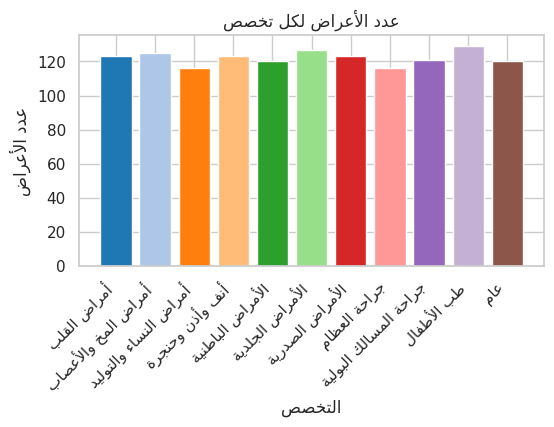

In [ ]:
import arabic_reshaper
from bidi.algorithm import get_display
import random

plt.figure(figsize=(6, 3))
sns.set(style='whitegrid')

nums_of_sym = df.groupby('label')['text'].count()
labels = [get_display(arabic_reshaper.reshape(label)) for label in nums_of_sym .index]
colors = [plt.cm.tab20(i) for i in range(len(nums_of_sym ))]
bars = plt.bar(labels, nums_of_sym .values, color=colors)

plt.xlabel(get_display(arabic_reshaper.reshape('التخصص')))
plt.ylabel(get_display(arabic_reshaper.reshape('عدد الأعراض')))
plt.title(get_display(arabic_reshaper.reshape('عدد الأعراض لكل تخصص')))

plt.xticks(rotation=45, ha='right')

plt.show()

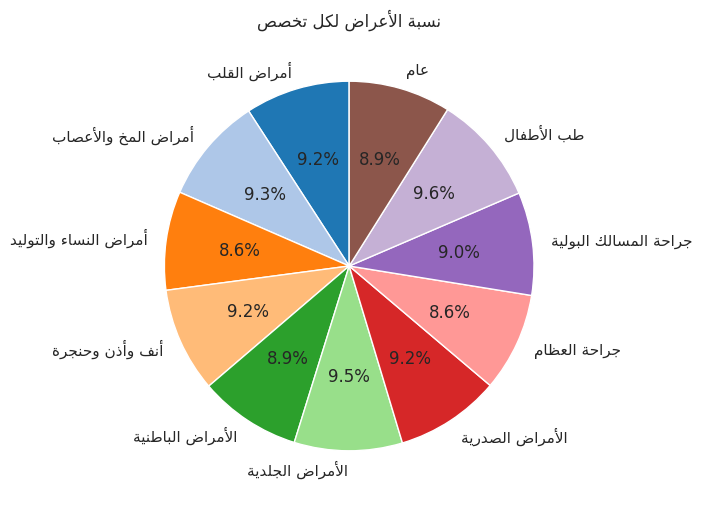

In [ ]:
plt.figure(figsize=(10, 6))
sns.set(style='whitegrid')
nums_of_sym = df.groupby('label')['text'].count()
labels = [get_display(arabic_reshaper.reshape(label)) for label in nums_of_sym.index]
colors = plt.cm.tab20.colors

plt.pie(nums_of_sym.values, labels=labels, autopct='%1.1f%%', colors=colors[:len(labels)], startangle=90)
plt.title(get_display(arabic_reshaper.reshape('نسبة الأعراض لكل تخصص')))
plt.show()

## Text Preprocessing
Clean the Arabic text: remove tashkeel, normalize Arabic characters, and strip non-Arabic symbols.

In [ ]:
pip install pyarabic

In [ ]:
from pyarabic.araby import strip_tashkeel
df['text']=df['text'].apply(lambda x:strip_tashkeel(x))

In [ ]:
import re

def normalize_arabic(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'[^ء-ي\s]', '', text)
    text = " ".join(text.split())

    return text

In [ ]:
import re
df['text'] = df['text'].apply(lambda x: re.sub(r'[^ء-ي0-9\s]', '', x))
df['label'] = df['label'].apply(lambda x: re.sub(r'[^ء-ي0-9\s]', '', x))

## Label Encoding & Train/Test Split
Encode specialty labels as integers and split data into training and test sets (75/25).


In [ ]:
import re
import torch
import transformers
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import accuracy_score

In [ ]:
le=LabelEncoder()
df['label']=le.fit_transform(df['label'])
df['label'].unique()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],df['label'],
    test_size=0.25,
    random_state=42,
    stratify=df['label'],
    shuffle=True)

## Tokenization & Dataset
Tokenize text using the AraBERT tokenizer and wrap the data in a PyTorch Dataset.

In [ ]:
model_name = "aubmindlab/bert-base-arabertv02"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=128)
test_encodings  = tokenizer(list(X_test), truncation=True, padding=True, max_length=128)

In [ ]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = MyDataset(train_encodings, list(y_train))
test_dataset  = MyDataset(test_encodings, list(y_test))

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=11,
    ignore_mismatched_sizes=True
)


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = torch.argmax(torch.tensor(predictions), dim=1)
    accuracy = accuracy_score(labels, predictions)
    return {"accuracy": accuracy}

## Model Training
Configure training arguments and run fine-tuning with HuggingFace Trainer.

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    weight_decay=0.01,
    fp16=True,

    report_to="none"
)



In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,2.172143,1.794815,0.541667
2,1.452474,1.004220,0.836310
3,0.724323,0.450489,0.916667
4,0.338517,0.269550,0.940476
5,0.179993,0.194968,0.958333
6,0.089879,0.166985,0.952381
7,0.055794,0.174948,0.958333
8,0.028970,0.136791,0.964286
9,0.021690,0.120850,0.970238
10,0.017688,0.129829,0.970238


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=630, training_loss=0.5081470720351688, metrics={'train_runtime': 306.6235, 'train_samples_per_second': 32.842, 'train_steps_per_second': 2.055, 'total_flos': 170784179986860.0, 'train_loss': 0.5081470720351688, 'epoch': 10.0})

## Evaluation
Evaluate model performance: accuracy, F1-score, confusion matrix, and classification report.

In [ ]:
from transformers.utils import notebook
trainer.remove_callback(notebook.NotebookProgressCallback)
results = trainer.evaluate()
print("Evaluation results:", results)

In [ ]:
y_pred_prob = trainer.predict(test_dataset).predictions
y_pred = np.argmax(y_pred_prob, axis=1)
y_test = np.array(test_dataset.labels)

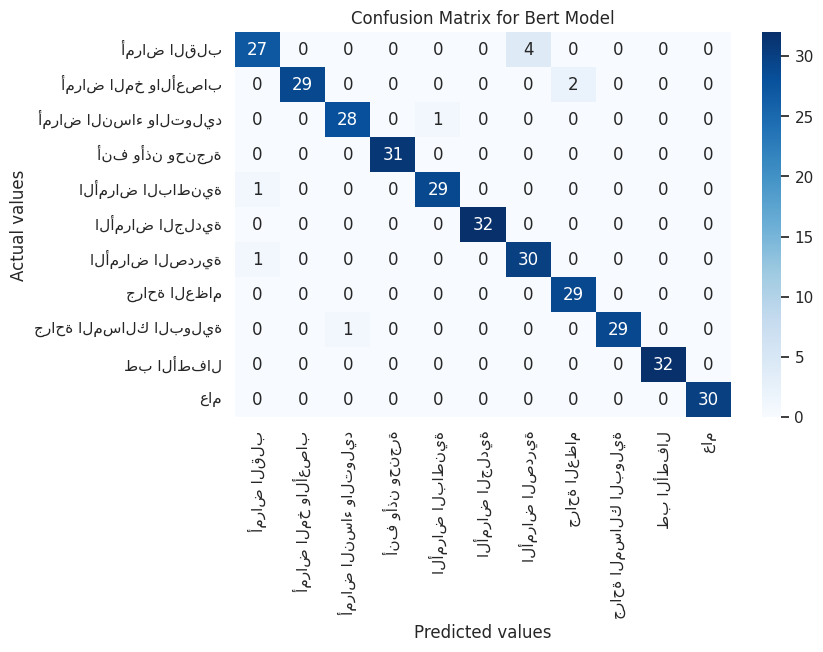

In [ ]:
CM = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,5))
sns.heatmap(data=CM, annot=True,fmt='g', cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.title('Confusion Matrix for Bert Model')
plt.show()

In [ ]:
report = classification_report(y_test, y_pred, output_dict=True,target_names=le.classes_)
df_report = pd.DataFrame(report).transpose()
df_report

,precision,recall,f1-score,support
أمراض القلب,0.931034,0.870968,0.900000,31.000000
أمراض المخ والأعصاب,1.000000,0.935484,0.966667,31.000000
أمراض النساء والتوليد,0.965517,0.965517,0.965517,29.000000
أنف وأذن وحنجرة,1.000000,1.000000,1.000000,31.000000
الأمراض الباطنية,0.966667,0.966667,0.966667,30.000000
الأمراض الجلدية,1.000000,1.000000,1.000000,32.000000
الأمراض الصدرية,0.882353,0.967742,0.923077,31.000000
جراحة العظام,0.935484,1.000000,0.966667,29.000000
جراحة المسالك البولية,1.000000,0.966667,0.983051,30.000000
طب الأطفال,1.000000,1.000000,1.000000,32.000000


## Inference with Confidence Threshold
Run predictions on new text. Any prediction with confidence below 0.5 is rejected as uncertain.

In [ ]:
import re
import torch
import torch.nn.functional as F


def normalize_arabic(text):
    tashkeel = re.compile(r'[\u0617-\u061A\u064B-\u0652]')
    text = re.sub(tashkeel, '', text)

    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub("ة", "ه", text)

    text = re.sub(r'[^\w\s]', '', text)

    return text

def predict_specialty(text, threshold=0.7):
    text = normalize_arabic(text)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    model.eval()

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)

    confidence, pred_id = torch.max(probs, dim=1)

    confidence = confidence.item()
    pred_id = pred_id.item()

    if confidence < threshold:
        return f"❌ غير واضح (confidence={confidence:.2f}) - استشر طبيب عام"

    pred_label = le.inverse_transform([pred_id])[0]
    return f"✅ {pred_label} (confidence={confidence:.2f})"



def handle_user_input(text):
    result = predict_specialty(text)
    print(result)


while True:

    user_input = input("اكتب الأعراض: ")

    if user_input.strip() == "":
        break

    handle_user_input(user_input)

## Save Model Artifacts
Save the fine-tuned model, tokenizer, and label encoder for future use.

In [ ]:
model.save_pretrained(model_name)


print("✅ تم حفظ الموديل بنجاح! تقدري دلوقتي تستخدميه في أي وقت.")


In [ ]:
tokenizer.save_pretrained(model_name)

In [ ]:
import joblib
joblib.dump(le,'label_encoder.pkl')

In [ ]:
import transformers
print(transformers.__version__)

## Project Pipeline

A summary of the full workflow from raw text to final prediction.

**Steps:**

1. **Setup** - Install libraries, import packages (numpy, pandas, torch, transformers)
2. **Data Preparation** - Define raw CSV symptom data and write to disk
3. **Load & Merge** - Load 4 CSV files, combine into one DataFrame (~dataset)
4. **EDA** - Check shape, label counts, nulls, duplicates
5. **Visualization** - Bar chart of specialty distribution
6. **Preprocessing** - Remove tashkeel, normalize alef variants, strip non-Arabic characters
7. **Encoding & Split** - LabelEncoder for specialties, 75% train / 25% test split
8. **Tokenization** - AraBERT tokenizer (max_length=128), wrapped in PyTorch Dataset
9. **Training** - Fine-tune AraBERT for 10 epochs, lr=2e-5, batch=16
10. **Evaluation** - Accuracy, weighted F1, confusion matrix, per-class report
11. **Thresholding & Uncertainty Handling** - Predict specialty; reject prediction if confidence < 0.7
12. **Save** - Save model weights, tokenizer, and label encoder (.pkl)